# Neural Architecture Search Applied to the Authorship Verification Problem
Luis Ignacio Ferro Salinas A01378248
Dr. Víctor Adrián Sosa Hernández
Dr. Esteban Castillo Juárez


In [1]:
import torch.nn as nn
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import random
import time
import os
from copy import deepcopy
import numpy as np
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
from datasets import Dataset, Features, Value, ClassLabel, IterableDataset
# from transformers import AutoTokenizer, AutoModel
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
import nltk
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize
from sklearn.model_selection import RandomizedSearchCV, train_test_split, KFold
from sklearn.svm import SVC
# from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# from gensim.models import Word2Vec
import gensim
import gensim.downloader
from nltk.tokenize import sent_tokenize, word_tokenize
import warnings
from enum import Enum
# from itertools import combinations
# from torch.cuda.amp import autocast, GradScaler
import shutil
from torch.utils.tensorboard import SummaryWriter
warnings.filterwarnings(action='ignore')

 

Style for the figures

In [2]:
plt.style.use('ggplot')

For reproducibility

In [3]:
os.environ["CUBLAS_WORKSPACE_CONFIG"]=":16:8"
# can be 4096:8

## Functions auxiliary to the pre-processing

In [4]:
def debug(thing, title):
    print('----------------------------------------------------')
    print(title)
    print(thing)
    print('----------------------------------------------------')

In [5]:
def split_data(training_data, testing_data):
    """ Transforms the data from DataFrames to lists of documents and labels.
    
    Input:
    training_data: DataFrame -> columns problem id, text1, text2, and label.
    test_data: DataFrame -> same columns.

    Returns:
    X_train: list[str] -> The list of training documents.
    y_train: list[int] -> The list of training labels.
    X_test: list[str] -> The list of test documents.
    y_test = list[int] -> The list of test labels
    """

    X_train = []
    y_train = []
    X_test = []
    y_test = []

    for i in range(len(training_data.index)):
        row = training_data.iloc[i]
        X_train += [row['text1']]
        X_train += [row['text2']]
        y_train += [row['label']]

    for i in range(len(testing_data.index)):
        row = testing_data.iloc[i]
        X_test += [row['text1']]
        X_test += [row['text2']]
        y_test += [row['label']]
    return X_train, y_train, X_test, y_test

In [6]:
def word_tokenize_docs(X, y):
    """ Tokenizes and lowers the words in X collection of documents.
    
    Input:
    X: list[str] -> the list of documents.
    y: list[int] -> a list of labels.
    
    Returns
    data: list[list] -> a list of lists of tokens, that have been lowered.
    y -> list[int] -> the list of labels.
    """
    
    debug('word_tokenize_docs', '')
    debug(type(X[0]), 'X first type')
    debug(y, 'y')

    data = []

    for document in X:
        document = document.replace("\n", " ")
        temp = []
        for cap_tword in word_tokenize(document):
            temp.append(cap_tword.lower())

        data.append(temp)
    return data, y

In [7]:
def split_chunks(word_list, chunk_length):
    """ Splits a list of words into a list of chunks"""

    chunk_ints = np.arange(0, len(word_list), chunk_length)

    chunks = []

    for i, start_int in enumerate(chunk_ints):
        if i == len(chunk_ints) - 1:
            chunki = ' '.join(word_list[start_int:])
            chunks += [chunki]
            continue
        end_int = chunk_ints[i + 1]
        chunki = ' '.join(word_list[start_int:end_int])
        chunks += [chunki]

    return chunks, len(chunks)

In [8]:
def split_dataset(x, y, chunk_length):
    """ Splits a dataset into chunks."""

    X = []

    chunks_pdoc = []

    for i in range(0, len(x) - 1, 2):
        text1_chunks, text1_nchunks = split_chunks(x[i], chunk_length)
        text2_chunks, text2_nchunks = split_chunks(x[i + 1], chunk_length)

        for t1_chunk in text1_chunks:
            X += [t1_chunk]

        chunks_pdoc += [text1_nchunks]

        for t2_chunk in text2_chunks:
            X += [t2_chunk]

        chunks_pdoc += [text2_nchunks]

    # Chunks per document.
    return X, y, chunks_pdoc

In [9]:
def make_df(X, Y):
    """ Creates dataframe with list of documents and list of labels.
    
    Input:
    X: list[str] -> a list of documents, where the documents are arranged
                    as known doc1, unknown doc1, known doc2, unknown doc2, etc.
    Y: list[int] -> a list of labels whose length matches the number of problems.
    
    Returns:
    df: DataFrame -> The dataframe with the documents in one column and labels
                     the other column.
    """
    
    X = pd.DataFrame(X, columns=['text'])
    Y = pd.DataFrame(Y, columns=['label'])
    
    df = pd.DataFrame()
    df['text'] = X
    df['label'] = Y

    df = df.fillna(-1)
    df['label'] = df['label'].astype('int')
    
    return df

In [10]:
def my_generator(n, df):
        for i in range(len(df.index)):
            yield {"text": df['text'].iloc[i], "label": df['label'].iloc[i]}

def create_iterableds(df):
    #class_names = list(df['label'].unique())
    data_features = Features({'text': Value('string'),
                              'label': ClassLabel(names=[1, 0, -1])})
    n_examples = df.shape[0]
    my_iterable_dataset = IterableDataset.from_generator(my_generator,
                                gen_kwargs={"n": n_examples, "df": df},
                                features=data_features,)
    return my_iterable_dataset

A toy dataset

In [11]:
toy_training_data = pd.DataFrame()

# Author 1 Donald Trump elections
# Author 2 music

toy_training_data['problem id'] = ['1', '2', '3']
toy_training_data['text1'] = ['Donald Trump wins.',
                              'Donald Trump called egotistical!',
                              'The Lumineers, release single.']
toy_training_data['text2'] = ['Trump tariffs imposed yesterday!',
                              'Kygo, headlines concert.',
                              'Kygo collaborates on single.']
toy_training_data['label'] = ['1', '0', '1']

toy_testing_data = pd.DataFrame()
toy_testing_data['problem id'] = ['1te', '2te', '3te']

toy_testing_data['text1'] = ['Trump addresses WEF!',
                             'Kygo, new single',
                             'New music, coming soon.']
toy_testing_data['text2'] = ['Scheimbaum responds to Trump.',
                             'Letter by Trump!',
                             'Trump does it again!']
toy_testing_data['label'] = ['1', '0', '0']

In [12]:
toy_training_data.to_csv('training.csv', sep='\\')
toy_testing_data.to_csv('test.csv', sep='\\')

In [13]:

def get_uch_dfs(path_to_save,
                year,
                language,
                doc_type,
                test_subset):
    """ Function to take the csv file of the dataset and load it.

    Input:
    path_to_save: str -> The path where the csv files are saved.
    year: int | str -> The year of the CLEF-PAN dataset used
    language: str -> The language of the dataset.
    doc_type: str -> The type of document for the dataset (e.g. 2014 has essays
                     and novels).
    test_subset: int -> The test subset used (e.g. 2014 essays has 2 test subsets) 
    
    Returns:
    train_dfuch: DataFrame -> The dataframe with the training data.
    training_cpduch: list[int] -> The chunks per document for the training data.
    y_train: list[int] -> The list of labels for the training data.
    test_dfuch: DataFrame -> The dataframe with the test data.
    test_cpduch: list[int] -> The chunks per document for the test data.
    y_test: list[int] -> The list of labels for the test data.
    """
    
    if year == 2020:
        # s for small it's not the entire dataset too large
        training_datas = pd.read_csv(os.path.join(path_to_save,
                                                'training_data2020s.csv'), sep='\\')
        testing_datas = pd.read_csv(os.path.join(path_to_save,
                                            'testing_data2020s.csv'), sep='\\')
    elif year == 2015:
        if language == "En":
            training_data = pd.read_csv(os.path.join(path_to_save,
                                                'training_data2015En.csv'), sep='\\')
            testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'testing_data2015En.csv'), sep='\\')

        elif language == "Es":
            training_data = pd.read_csv(os.path.join(path_to_save,
                                                'training_data2015Es.csv'), sep='\\')
            testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'testing_data2015Es.csv'), sep='\\')
    elif year == 2014:
        if language == "En":
            if doc_type == 'Essay':
                training_data = pd.read_csv(os.path.join(path_to_save,
                                                'training_data2014EnEssay.csv'), sep='\\')
                if test_subset == 1:
                    testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'testing_data2014EnEssay1.csv'), sep='\\')
                elif test_subset == 2:
                    testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'testing_data2014EnEssay2.csv'), sep='\\')

            elif doc_type == 'Novel':
                training_data = pd.read_csv(os.path.join(path_to_save,
                                                'training_data2014EnNovel.csv'), sep='\\')
                if test_subset == 1:
                    testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'testing_data2014EnNovel1.csv'), sep='\\')
                elif test_subset == 2:
                    testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'testing_data2014EnNovel2.csv'), sep='\\')

        elif language == "Es":
            ...
    elif year == 2013:
        if language == "En":
            training_data = pd.read_csv(os.path.join(path_to_save,
                                                'training_data2013En.csv'), sep='\\')
            testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'testing_data2013En.csv'), sep='\\')

        elif language == "Es":
            training_data = pd.read_csv(os.path.join(path_to_save,
                                                'training_data2013Es.csv'), sep='\\')
            testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'testing_data2013Es.csv'), sep='\\')
    elif year == 'all':
        # for now only english
        training_data = pd.read_csv(os.path.join(path_to_save,
                                                'big_guy_training.csv'), sep='\\')
        testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'big_guy_test.csv'), sep='\\')
    elif year == 'allR':
        # for now only english
        training_data = pd.read_csv(os.path.join(path_to_save,
                                                'training_bgrs.csv'), sep='\\')
        testing_data = pd.read_csv(os.path.join(path_to_save,
                                                'test_bgrs.csv'), sep='\\')

    # Toy debugging methodology.

    if year == 2020:
        X_train, y_train, X_test, y_test = \
            split_data(training_datas, testing_datas)
    elif year == 2015 or year == 2013 or year == 2014 or year == 'all' or year == 'allR':
        X_train, y_train, X_test, y_test = \
            split_data(training_data, testing_data)
        
    debug('Training and test splits created', '')
    debug(len(y_train), 'Training examples')
    debug(len(y_test), 'Test examples')

    X_trainuch = X_train 
    X_testuch = X_test

    train_dfuch = make_df(X_trainuch, y_train)
    test_dfuch = make_df(X_testuch, y_test)

    debug(train_dfuch.head(), f'DataFrames created')

    training_cpduch = [1] * len(y_train) * 2
    test_cpduch = [1] * len(y_test) * 2

    return train_dfuch, training_cpduch, y_train, test_dfuch, test_cpduch, y_test



In [14]:
def load_embeddings(embeddings_path,
                    year,
                    language,
                    doc_type,
                    test_subset):
    
    """ Load the precalculated embeddings.
    
    Input:
    embeddings_path: str -> the path where the embeddings are saved.
    year: int | str -> The year of the CLEF-PAN dataset used
    language: str -> The language of the dataset.
    doc_type: str -> The type of document for the dataset (e.g. 2014 has essays
                     and novels).
    test_subset: int -> The test subset used (e.g. 2014 essays has 2 test subsets) 
    
    Returns:
    train_tfidfs: Tensor -> The TF-IDFs for the training set. 
    test_tfidfs: Tensor -> The TF-IDFs for the test set.
    training_wembs: Tensor -> The normalized sum of word embeddings of the 
                              training set.
    test_wembs: Tensor -> The normalized sum of word embeddings of the 
                        training set
    """

    if year == 2020:
        train_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTrainingNoChunkYear2020.pt')
        test_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTestNoChunkYear2020.pt')
        
        training_wembsp = os.path.join(embeddings_path, 'double_training_wembs_nochunks_glove300_year2020.pt')
        test_wembsp = os.path.join(embeddings_path, 'double_test_wembs_nochunks_glove300_year2020.pt')
        
    elif year == 2015:
        if language == "En":
            train_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTrainingNoChunkYear2015.pt')
            test_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTestNoChunkYear2015.pt')
            
            training_wembsp = os.path.join(embeddings_path, 'double_training_wembs_nochunks_glove300_year2015.pt')
            test_wembsp = os.path.join(embeddings_path, 'double_test_wembs_nochunks_glove300_year2015.pt')
            

        elif language == "Es":
            ...

    elif year == 2014:
        if language == "En":
            if doc_type == 'Essay':
                
                if test_subset == 1:
                    ...
                elif test_subset == 2:
                    train_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTrainingNoChunkYear2014Essay2.pt')
                    test_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTestNoChunkYear2014Essay2.pt')
                    
                    training_wembsp = os.path.join(embeddings_path, 'double_training_wembs_nochunks_glove300_year2014Essay2.pt')
                    test_wembsp = os.path.join(embeddings_path, 'double_test_wembs_nochunks_glove300_year2014Essay2.pt')
                    

            elif doc_type == 'Novel':
                
                if test_subset == 1:
                    ...
                elif test_subset == 2:
                    train_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTrainingNoChunkYear2014Novel2.pt')
                    test_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTestNoChunkYear2014Novel2.pt')
                    
                    training_wembsp = os.path.join(embeddings_path, 'double_training_wembs_nochunks_glove300_year2014Novel2.pt')
                    test_wembsp = os.path.join(embeddings_path, 'double_test_wembs_nochunks_glove300_year2014Novel2.pt')
                    

        elif language == "Es":
            ...
    elif year == 2013:
        if language == "En":
            train_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTrainingNoChunkYear2013.pt')
            test_tfidfsp = os.path.join(embeddings_path, 'Double2GramPosTfidfsBetterTestNoChunkYear2013.pt')
            
            training_wembsp = os.path.join(embeddings_path, 'double_training_wembs_nochunks_glove300_year2013.pt')
            test_wembsp = os.path.join(embeddings_path, 'double_test_wembs_nochunks_glove300_year2013.pt')
            

        elif language == "Es":
            ...
    elif year == 'all':
        ...        
    train_tfidfs, test_tfidfs = torch.load(train_tfidfsp), torch.load(test_tfidfsp)
    training_wembs = torch.load(training_wembsp)
    test_wembs = torch.load(test_wembsp)
    
    debug('Pre-calculated embeddings loaded', '')
    debug(train_tfidfs.shape, 'Training TF-IDFs embeddings shape')
    debug(test_tfidfs.shape, 'Test TF-IDFs embeddings shape')
    debug(training_wembs.shape, 'Training word embeddings shape')
    debug(test_wembs.shape, 'Test word embeddings shape')

    return train_tfidfs, test_tfidfs, training_wembs, test_wembs
    
    

## Loading the information for a given dataset

In [116]:
path_to_save = 'preprocessedDatasets'
embeddings_path = os.path.join('preprocessedEmbeddings', 'float64')
year = 2015
language = 'En'
doc_type = 'Novel'
test_subset = 2
chunk_size = 500
syn_embsz = 685

train_dfuch, training_cpduch, y_train, test_dfuch, test_cpduch, y_test = get_uch_dfs(path_to_save,
                                                                    year,
                                                                    language,
                                                                    doc_type,
                                                                    test_subset)

train_tfidfs, test_tfidfs, training_wembs, test_wembs = load_embeddings(embeddings_path,
                                                                        year,
                                                                        language,
                                                                        doc_type,
                                                                        test_subset)

----------------------------------------------------

Training and test splits created
----------------------------------------------------
----------------------------------------------------
Training examples
100
----------------------------------------------------
----------------------------------------------------
Test examples
500
----------------------------------------------------
----------------------------------------------------
DataFrames created
                                                text  label
0   My, my, I was forgetting all about\nthe child...      1
1  Oh, he's coming, he's\ncoming. I'm going to ge...      0
2                               \n     \n  \t    ...      0
3  \n     But speed thy steps, the cold will work...      0
4  God!  What beauty!\n\nUmm?\n\nI said: God!  Wh...      1
----------------------------------------------------
----------------------------------------------------

Pre-calculated embeddings loaded
------------------------------------

The shapes of the DataFrames with the information

In [117]:

debug(train_dfuch.shape, 'Training DataFrame shape')
debug(test_dfuch.shape, 'Test DataFrame shape')

----------------------------------------------------
Training DataFrame shape
(200, 2)
----------------------------------------------------
----------------------------------------------------
Test DataFrame shape
(1000, 2)
----------------------------------------------------


## Functions to obtain the pre-calculated embeddings

In [118]:

def get_pos_df(df):
    """Replace words with POS tags in new DataFrame.
    
    Input:
    df: DataFrame -> Contains the documents and the labels.

    Returns:
    pdf: DataFrame -> Has replaced the words for POS tags.
    """
    
    # Prepare an empty list to store the results
    result_rows = []
    
    for i, sentence in enumerate(df['text']):
        debug(i, f'{i} index')
        s_tokenized = sent_tokenize(sentence)
        
        # Collect all tags in one list for this sentence
        tagss = []
        for ste in s_tokenized:
            words = [w.lower() for w in word_tokenize(ste)]
            w_tags = nltk.pos_tag(words)
            tags = " ".join([tag for _, tag in w_tags])
            tagss.append(tags)
        
        # Join all sentence tags and append to results
        result_rows.append(" ".join(tagss))
    
    # Convert the list of POS tags into a DataFrame
    pdf = pd.DataFrame(result_rows, columns=['text'])
    
    # Copy the 'label' column and set the correct index
    pdf['label'] = df['label'].values
    pdf.index = df.index
    
    return pdf
# training_pdf = get_pos_df(train_dfuch)
# test_pdf = get_pos_df(test_dfuch)
# debug(training_pdf, 'training pos df')
# debug(test_pdf, 'test pos df')

In [119]:
def get_tfidf_df(dfs):
    """Create tensors of Tf-IDFs using dfs[0] to learn vocabulary.
    
    Input:
    dfs: tuple[DataFrame] -> The first DataFrame is for training, the second
                             is for testing.

    Returns:
    tfidf_training_tensor: Tensor -> The trained TF-IDF values for the training set. 
    tfidf_test_tensor: Tensor -> The TF-IDF values for the test set.
    tfidf: TfidfVectorizer -> The TF-IDF vectorizer instance.
    """ 

    df_training, df_test = dfs
    tfidf = TfidfVectorizer(ngram_range=(2, 2))

    # Get tf-idf values. Learn vocabulary from training set.
    tfidf_training = tfidf.fit_transform(list(df_training['text'])).toarray()
    # Use known vocabulary to calculate test set.
    tfidf_test = tfidf.transform(list(df_test['text'])).toarray()

    # Convert training TF-IDF to float64 and move to GPU
    tfidf_training_tensor = torch.from_numpy(tfidf_training).double().to('cuda')

    # Convert test TF-IDF to float64 and move to GPU
    tfidf_test_tensor = torch.from_numpy(tfidf_test).double().to('cuda')

    return tfidf_training_tensor, tfidf_test_tensor, tfidf


# train_tfidfs, test_tfidfs, tfidfV = get_tfidf_df((training_pdf, test_pdf))

In [120]:
'''train_tfidfs_sum = torch.sum(train_tfidfs, dim=0)
train_tfidfs_sum.shape
# top pos 2 grams training
top_pos2gstr = sorted(range(train_tfidfs_sum.shape[0]), key=lambda x: train_tfidfs_sum[x])
top_pos2gstr[:10]

test_tfidfs_sum = torch.sum(test_tfidfs, dim=0)
test_tfidfs_sum.shape
# top pos 2 grams test
top_pos2gste = sorted(range(test_tfidfs_sum.shape[0]), key=lambda x: test_tfidfs_sum[x])
top_pos2gste[:10]
'''

'train_tfidfs_sum = torch.sum(train_tfidfs, dim=0)\ntrain_tfidfs_sum.shape\n# top pos 2 grams training\ntop_pos2gstr = sorted(range(train_tfidfs_sum.shape[0]), key=lambda x: train_tfidfs_sum[x])\ntop_pos2gstr[:10]\n\ntest_tfidfs_sum = torch.sum(test_tfidfs, dim=0)\ntest_tfidfs_sum.shape\n# top pos 2 grams test\ntop_pos2gste = sorted(range(test_tfidfs_sum.shape[0]), key=lambda x: test_tfidfs_sum[x])\ntop_pos2gste[:10]\n'

In [121]:

def get_doc2vec_embs(df_training, df_test):
    """ Attempt to use document embeddings."""

    data = list(df_training['text']) + list(df_test['text'])
    
    # preproces the documents, and create TaggedDocuments
    tagged_data = [TaggedDocument(words=word_tokenize(doc.lower()),
                                tags=[str(i)]) for i,
                doc in enumerate(data)]
    
    # train the Doc2vec model
    model = Doc2Vec(vector_size=128,
                    min_count=2, epochs=50)
    model.build_vocab(tagged_data)
    model.train(tagged_data,
                total_examples=model.corpus_count,
                epochs=model.epochs)
    
    # get the document vectors
    document_vectors = [model.infer_vector(
        word_tokenize(doc.lower())) for doc in data]
    
    embeddings = torch.empty((0, 128)).to('cuda')

    for embedding in document_vectors:
        embeddings = torch.cat((embeddings, embedding.reshape(1, 128)), dim=1)

    return embeddings



In [122]:
def get_punctuation_bow(df_training, df_test):
    """Calculate bag of punctuations for the input document DataFrames.
    
    Input:
    df_training: DataFrame -> contains training examples in the single-column
                              format.
    df_test: DataFrame -> contains test examples in the single-column
                              format.

    Returns:
    puncs_train: Tensor -> The bag-of-punctuation marks for the training set.
    puncs_test: Tensor -> The bag-of-punctuation marks for the test set.
    """ 

    training_counts = []
    for i in df_training.index:
        curr_chunk = df_training.loc[i]['text']
        curr_count = [0] * 32
        for char in curr_chunk:
            if char in string.punctuation:
                # The position in the array matches that of punctuation.
                curr_count[string.punctuation.index(char)] += 1
        training_counts += [curr_count]

    test_counts = []
    for i in df_test.index:
        curr_chunk = df_test.loc[i]['text']
        curr_count = [0] * 32
        for char in curr_chunk:
            if char in string.punctuation:
                curr_count[string.punctuation.index(char)] += 1
        test_counts += [curr_count]

    puncs_train = nn.functional.normalize(torch.DoubleTensor(training_counts).to('cuda'), dim=1)
    puncs_test = nn.functional.normalize(torch.DoubleTensor(test_counts).to('cuda'), dim=1)

    return puncs_train, puncs_test

puncs_train, puncs_test = get_punctuation_bow(train_dfuch, test_dfuch)
debug(puncs_train.shape, 'punctuations train before')
debug(puncs_test.shape, 'punctuations test before')



----------------------------------------------------
punctuations train before
torch.Size([200, 32])
----------------------------------------------------
----------------------------------------------------
punctuations test before
torch.Size([1000, 32])
----------------------------------------------------


### Code to train word embeddings from scratch

In [123]:
'''
all_string = ''

for text in train_dfuch['text'].values:
    all_string += text
for text in test_dfuch['text'].values:
    all_string += text
print(len(all_string))'''

"\nall_string = ''\n\nfor text in train_dfuch['text'].values:\n    all_string += text\nfor text in test_dfuch['text'].values:\n    all_string += text\nprint(len(all_string))"

In [124]:
'''
data = []
 
# iterate through each sentence in the file
for i in sent_tokenize(all_string):
    temp = []
 
    # tokenize the sentence into words
    for j in word_tokenize(i):
        temp.append(j.lower())
 
    data.append(temp)
 
# Create CBOW model
model1 = gensim.models.Word2Vec(data, min_count=1,
                                vector_size=256, window=5)
embedding_dict = model1.wv'''
# Create Skip Gram model
#model1 = gensim.models.Word2Vec(data, min_count=1, vector_size=100,
#                                window=5, sg=1)
 


'\ndata = []\n \n# iterate through each sentence in the file\nfor i in sent_tokenize(all_string):\n    temp = []\n \n    # tokenize the sentence into words\n    for j in word_tokenize(i):\n        temp.append(j.lower())\n \n    data.append(temp)\n \n# Create CBOW model\nmodel1 = gensim.models.Word2Vec(data, min_count=1,\n                                vector_size=256, window=5)\nembedding_dict = model1.wv'

### Code to use pretrained word embeddings

In [125]:

# Pretrained word embedding model

# embedding_dict = gensim.downloader.load('glove-wiki-gigaword-300')

In [126]:
def get_wembs_df(df, embedding_dict, wemb_size=300):
    """ Use an embedding dictionary to calculate the embeddings of texts in df.
    
    Input:
    df: DataFrame -> Contains the documents and the labels.
    embedding_dict: gensim.models.keyedvectors.KeyedVectors -> word embedding
                                                               dictionary.

    Returns:
    wembs: Tensor -> Contains the normalized sum of word embeddings for all 
                     documents.
    """
    
    n_docs = len(df)
    # Pre-allocate the embeddings tensor
    wembs = torch.zeros((n_docs, wemb_size), dtype=torch.float64, device='cuda')

    for ind, text in enumerate(df['text'].values):
        debug(ind, f'doc index out of {n_docs}')
        doc_embeddings = []
        # Iterate through each sentence in the document.
        for sentence in sent_tokenize(text):
            sentence_embeddings = []
            # Tokenize the sentence into words.
            for word in word_tokenize(sentence):
                try:
                    # Get embedding of lowercase version of the word.
                    word_embeddings = embedding_dict[word.lower()]
                    sentence_embeddings.append(word_embeddings)
                except KeyError:
                    # If glove does not know the word, ignore it.
                    continue

            if sentence_embeddings:
                sentence_tensor = torch.tensor(np.array(sentence_embeddings), dtype=torch.float64, device='cuda')
                # Combine all word embeddings of a sentence by sum.
                doc_embeddings.append(torch.sum(sentence_tensor, dim=0))

        if doc_embeddings:
            doc_tensor = torch.stack(doc_embeddings)
            # Combine all sentence embeddings of a document by sum.
            wembs[ind] = torch.sum(doc_tensor, dim=0)
        else:
            wembs[ind] = torch.zeros(wemb_size, dtype=torch.float64, device='cuda')

    # Normalize the embeddings
    wembs = torch.nn.functional.normalize(wembs, dim=1)

    return wembs

# training_wembs = get_wembs_df(train_dfuch, embedding_dict)
# test_wembs = get_wembs_df(test_dfuch, embedding_dict)



In [127]:
# torch.save(training_wembs, 'double_training_wembs_nochunks_glove300_year2020.pt')
# torch.save(test_wembs, 'double_test_wembs_nochunks_glove300_year2020.pt')

In [128]:
# Print results
'''print("Cosine similarity between 'computer' " +
      "and 'command' - CBOW : ",
      model1.wv.similarity('computer', 'command'))
 
print("Cosine similarity between 'computer' " +
      "and 'monsieur' - CBOW : ",
      model1.wv.similarity('computer', 'monsieur'))'''
 


'print("Cosine similarity between \'computer\' " +\n      "and \'command\' - CBOW : ",\n      model1.wv.similarity(\'computer\', \'command\'))\n \nprint("Cosine similarity between \'computer\' " +\n      "and \'monsieur\' - CBOW : ",\n      model1.wv.similarity(\'computer\', \'monsieur\'))'

## Neural Architecture Search classes

In [129]:

class RDropout(nn.Module):
    """ The implementation of Dropout Layer that ensures reproducibility
    with numpy."""
    
    def __init__(self,
                 percentage,
                 seed=None):
        super().__init__()
        self.percentage = percentage
        self.seed = None

    def forward(self, input, training=True):
        """Only turn off values in the training phase."""
        
        if training == True:
            rows, cols = input.shape

            if self.seed:
                cseed = self.seed
            else:
                cseed = cols
            np.random.seed(cseed)

            mask = torch.tensor(np.random.binomial(1,
                    1 - self.percentage, size=input.shape), device='cuda')
            return input * mask
        elif training == False:
            ...
        return input

We can see how the reproducible dropout always drops the same values.

In [130]:
A = torch.FloatTensor([[-0.3297,  0.6583, -0.0512,  0.3026, -0.5311,  0.4356],
                        [ 0.3293,  0.4174, -1.0000, -0.2259, -0.0132,  0.5133]]).to('cuda')
print(A.shape)
my_drop = RDropout(0.3)

example_dr = my_drop(A, True)
print(example_dr)
print(example_dr.shape)


torch.Size([2, 6])
tensor([[-0.0000,  0.6583, -0.0000,  0.3026, -0.5311,  0.4356],
        [ 0.3293,  0.4174, -1.0000, -0.2259, -0.0132,  0.0000]],
       device='cuda:0')
torch.Size([2, 6])


In [131]:
class Model(nn.Module):
    """Model class leveraging torch nn Module."""
    def __init__(self, 
                 encoding,
                 input_shape,
                 genel,
                 tel,
                 seed=None):
        super().__init__()

        self.seed = seed

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.encoding = encoding
        self.encoding_str = ','.join([str(gene) for gene in encoding])
        self.myparameters = []
        self.tel = tel
        # Gene length.
        self.genel = genel
        self.input_shape = input_shape
        self.flatten_conv = nn.Flatten(1, -1)
        self.identity = nn.Identity()
        self.dropout1 = RDropout(0.9, self.seed)
        self.dropout2 = RDropout(0.6, self.seed)
        self.dropout3 = RDropout(0.3, self.seed)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()
        self.leaky_relu = nn.LeakyReLU()
        
        # 7-19 Linears 20-23 convs
        self.int_to_mod = {0: self.identity, 
                           1: self.dropout1, 
                           2: self.dropout2, 
                           3: self.dropout3, 
                           4: self.relu, 
                           5: self.tanh, 
                           6: self.leaky_relu,
                           7: 1,
                           8: 2,
                           9: 4,
                           10: 8,
                           11: 16,
                           12: 32,
                           13: 64,
                           14: 128,
                           15: 256,
                           16: 512,
                           17: 1024,
                           18: 2048,
                           19: 4096,
                           20: (2, 2),
                           21: (2, 8),
                           22: (8, 2),
                           23: (8, 8),}

        self.sequential = self.build_sequential()
        debug(self, 'Model created')

        for simple_param in self.sequential.parameters():
            self.myparameters += [simple_param]

    def build_sequential(self):
        """Use encoding to build the actual PyTorch deep neural network.
        
        Input:
        None

        Returns:
        nn.Sequential -> The sequential model that is represented by this class.
        """
        
        # Modules list.
        mlist = []
        curr_shape = self.input_shape
        for i in range(0, len(self.encoding), self.genel):
            gene = self.encoding[i:i + self.genel][0]
            
            # Get the module corresponding to the integer.
            if gene < 7:
                # In this case (Identity, Dropout, Activation, BatchNorm1D the shape)
                # is unchanged.
                mlist += [self.int_to_mod[gene]]
            elif gene >= 7 and gene <= 19:
                # Linear layers.
                new_shape = self.int_to_mod[gene]
                cl = nn.Linear(curr_shape, new_shape)
                mlist += [cl]
                curr_shape = new_shape
                mlist += [nn.BatchNorm1d(curr_shape, dtype=torch.float64)]

            else:
                # Conv1D layers.
                # I make the rule that the Flatten will follow Conv1D always
                # to ensure that the input channels is always 1.
                kernel_size, channels = self.int_to_mod[gene]
                cc = nn.Conv1d(1, channels, kernel_size)
                mlist += [cc]
                mlist += [self.flatten_conv]
                i += 1
                if kernel_size > curr_shape:
                    new_shape = channels
                else:
                    new_shape = (curr_shape - kernel_size + 1) * channels
                curr_shape = new_shape
                mlist += [nn.BatchNorm1d(curr_shape, dtype=torch.float64)]
            #self.debug(curr_shape, 'curr shape')

        # Binary classification problem, ensure that the output is shape 1.
        mlist += [nn.Linear(curr_shape, 1)]
        return nn.Sequential(*mlist).to(self.device)

    def __str__(self):
        return 'ENCODING +' + str(self.sequential)

    def __eq__(self, other):
        if isinstance(other, Model):
            return self.encoding == other.encoding
        return False
    
    def debug(self, thing, title):
        print("--------------------------------------------------------")
        print(title)
        print(thing)
        print("--------------------------------------------------------")

    def compare_eots_ch(self, X_e, chunks_per_doc, e_length):
        """Combine chunk embeddings that belong to same document and problem.
        
        Input:
        X_e: Tensor -> Embedding tensor for the batch.
        chunks_per_doc: list[int] -> A list showcasing at position i, how 
                                    many chunks were used for document i.
        e_length: int -> The length of the embedding.
        
        Returns:
        X_compared: Tensor -> Contains the embedings of the same problem
                              instance in the same row.

        """

        X_doc_embs = []
        X_compared = []

        X_doc_embs = torch.empty((0, e_length)).to(self.device)

        i = 0
        # Current chunks per document.
        for curr_cpd in chunks_per_doc:
            p1 = torch.empty((0, e_length)).to(self.device)
            for j in range(curr_cpd):
                p1 = torch.cat((p1, X_e[i + j].reshape(1, e_length)), dim=0)
            # The embeddings of the document are combined with the mean.
            p1 = torch.mean(p1, dim=0)
            X_doc_embs = torch.cat((X_doc_embs, 
                                    p1.reshape(1, 
                                               e_length)), 
                                               dim=0)
            i = i + curr_cpd
        del X_e

        X_compared = torch.empty((0, e_length * 2)).to(self.device)

        for k in range(0, X_doc_embs.shape[0] - 1, 2):
            known_emb = X_doc_embs[k]
            unknown_emb = X_doc_embs[k + 1]

            # Concatenate document embeddings of same problem.
            l = torch.cat((known_emb, unknown_emb), dim=0)
            X_compared = torch.cat((X_compared, 
                                    l.reshape(1, 
                                              e_length * 2)), 
                                              dim=0)
        return X_compared


    def forward(self, cpd, embeddings):
        """Forward pass of the deep neural network.
        
        Input:
        cpd: list[int] -> a list that says at position i, how many 
                    chunks were used by document i.
        embeddings: Tensor -> The embeddings of the current batch.

        Returns: 
        out_l: Tensor -> The output of the forward pass.
        """
        
        X_e = embeddings

        # Input compared. 
        # Combine embeddings of same problem instance.
        inp_compd = self.compare_eots_ch(X_e, cpd, self.tel)
        #self.debug(inp_compd, "Problem-level embeddings")       

        # SECTION TO USE SEQUENTIAL
        #out = self.sequential(inp_compd).to(self.device)
        if isinstance(self.sequential[0], nn.Conv1d):
            # Match the shape format for Conv1D with 1 input channel.
            inp_compd = inp_compd.reshape(inp_compd.shape[0], 
                                          1, 
                                          inp_compd.shape[-1])
        
        if isinstance(self.sequential[0], RDropout):
            # The Dropout receives if the Model is in training phase or not.
            out = self.sequential[0](inp_compd, self.training).to(self.device)    
        else:
            out = self.sequential[0](inp_compd).to(self.device)

        '''if not isinstance(self.sequential[0], nn.Identity):
            self.debug(self.sequential[0], 'Current module')
            if hasattr(self.sequential[0], 'weight'):
                    self.debug(self.sequential[0].weight.data, 'Module\'s parameters')
            self.debug(out, 'Current output')'''

        for i, mod in enumerate(self.sequential[1:]):
            if isinstance(mod, nn.Conv1d):
                #self.debug(None, 'in conv reshaping')
                if mod.kernel_size[0] > out.shape[-1]:
                    # In the case where the kernel is larger than the current
                    # output shape, we pad with zeros to keep it valid.
                    out = nn.functional.pad(out, 
                                            (0,
                                             mod.kernel_size[0] - out.shape[-1]))
                out = out.reshape(out.shape[0], 1, out.shape[-1])

            if isinstance(mod, RDropout):
                out = mod(out, self.training).to(self.device) 
            else:
                out = mod(out).to(self.device)

            '''if not isinstance(mod, nn.Identity):
                self.debug(mod, 'Current module')
                if hasattr(mod, 'weight'):
                    self.debug(mod.weight.data, 'Module\'s parameters')
                self.debug(out, 'Current output')
                if isinstance(mod, nn.BatchNorm1d):
                    debug(mod.running_mean, 'run mean')
                    debug(mod.running_var, ' run var')'''

        out_l = out.squeeze(-1).to(self.device)
        #self.debug(out_l.shape, "out shape")

        return out_l   
    
    def parameters(self):
        return self.myparameters

    def weights_init_mod(self, module, seed):
        """Initialize the parameters of the a module, using a numpy seed."""

        module.bias.data = torch.zeros(module.bias.data.shape,
                                       dtype=torch.float64).to('cuda')

        np.random.seed(seed)
        module.weight.data = torch.DoubleTensor(\
            self.trunc(np.random.uniform(-1, 
                                        1, 
                                        module.weight.data.shape).\
                                            astype(np.float64), 
                                    decs=4)).to('cuda')
        
    def trunc(self, values, decs=0):
        """Function to truncate decimals."""
        return np.trunc(values*10**decs)/(10**decs)

    def weights_init_uniform(self):
        """Initialize own weights with uniform distribution."""
        for ind, mod in enumerate(self.sequential):
            if hasattr(mod, 'weight'):
                if self.seed:
                    cseed = ind * self.seed
                else:
                    cseed = ind
                self.weights_init_mod(mod, cseed)

    @classmethod
    def encoding_str2list(cls, encoding_as_str):
        """Get the integer list encoding from the str version."""
        return [int(gene) for gene in encoding_as_str.split(',')]
        

In [132]:
# model for graph
class Model_FG(nn.Module):
    def __init__(self,
                 encoding,
                 input_shape,
                 genel,
                 tel,
                 seed=None):
        
        super().__init__()
        self.seed = seed
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.encoding = encoding # a binary encoding
        self.encoding_str = ','.join([str(gene) for gene in encoding])
        self.myparameters = []
        self.tel = tel

        # Gene length.
        self.genel = genel
        self.input_shape = input_shape
        self.edges = self.generate_topological_edges()
        self.uniform_neurons = 64
        self.debug(self.edges, 'edges')

        self.graph, self.linear_mdict, self.bn_mdict = self.build_graph_mdicts(encoding)
        for node_str in self.linear_mdict:
            cmod_linear = self.linear_mdict[node_str]
            cmod_bn = self.bn_mdict[node_str]
            if hasattr(cmod_linear, 'weight'):
                for param in cmod_linear.parameters():
                    self.myparameters += [param]
            if hasattr(cmod_bn, 'weight'):
                for param in cmod_bn.parameters():
                    self.myparameters += [param]

        # self.debug(self.myparameters, 'my parameters')

    def debug(self, thing, title):
        print('------------------------------------------------')
        print(title)
        print(thing)
        print('------------------------------------------------')
    
    def generate_topological_edges(self, num_nodes=7):
        """Generates all possible topological edges for a given number of nodes."""

        edges = []
        for i in range(1, num_nodes + 1):
            for j in range(i + 1, num_nodes + 1):
                edges.append((i, j))
        return edges
    
    def build_graph_mdicts(self, encoding):
        graph = nx.DiGraph()

        # 7 nodes allow for 21 edges

        for i in range(len(encoding)):
            if encoding[i]:
                u, v = self.edges[i]
                graph.add_edge(u, v)

        # All modules are the same Linear 64

        linear_mdict = nn.ModuleDict()
        batch_norm_mdict = nn.ModuleDict()
        in_deg_it = graph.in_degree()        

        for node, in_deg in in_deg_it:
            if node == 7:
                linear_mdict[str(node)] = nn.Linear(in_deg * self.uniform_neurons, 1)
                batch_norm_mdict[str(node)] = nn.Identity()
            elif in_deg == 0:
                linear_mdict[str(node)] = nn.Linear(self.input_shape, self.uniform_neurons)
                batch_norm_mdict[str(node)] = nn.BatchNorm1d(self.uniform_neurons, dtype=torch.float64)
            else:
                # indegree not zero in hidden node
                linear_mdict[str(node)] = nn.Linear(in_deg * self.uniform_neurons, self.uniform_neurons)
                batch_norm_mdict[str(node)] = nn.BatchNorm1d(self.uniform_neurons, dtype=torch.float64)                    
        return graph, linear_mdict.to(self.device), batch_norm_mdict.to(self.device)


    def __str__(self):
        nx.draw(self.graph, with_labels=True, arrows=True, arrowstyle='->')
        plt.title('Drawing')

        layers_str = ''
        for label in self.labels:
            layers_str += f'module {label} = {(self.modules_dict[label])}\n'

        return layers_str
    
    def concatenate_predecessor_outputs(self, 
                                        target_node, 
                                        nodes_outs, 
                                        inp_compd):
        """
        Concatenates the torch tensors (outputs) of the predecessors of a node,
        and stores the corresponding output in nodes_outs in place.

        Args:
            G (nx.DiGraph): The directed graph.
            target_node: The node for which to concatenate predecessor outputs.
            nodes_outs (dict): A dictionary mapping nodes to their torch tensor outputs.

        Returns:
            None
        """

        predecessor_nodes = list(self.graph.predecessors(target_node))

        if not predecessor_nodes:
            x = self.linear_mdict[str(target_node)](inp_compd).to(self.device)
            # self.debug(x, f'linear output node {target_node}')
            # self.debug(self.bn_mdict[str(target_node)], 'batch norm module')
            # self.debug(self.bn_mdict[str(target_node)].state_dict(), 'batch norm module params')

            nodes_outs[target_node] = self.bn_mdict[str(target_node)](x).to(self.device)
            # self.debug(nodes_outs[target_node], f'batch norm output node {target_node}')
            return

        predecessor_outputs = [nodes_outs[node] for node in predecessor_nodes]

        concatenated_output = torch.cat(predecessor_outputs, dim=1) # concatenate along dim=1.

        x = self.linear_mdict[str(target_node)](concatenated_output).to(self.device)
        # self.debug(x, f'linear output node {target_node}')
        nodes_outs[target_node] = self.bn_mdict[str(target_node)](x).to(self.device)
        # self.debug(nodes_outs[target_node], f'batch norm output node {target_node}')

        return

    def compare_eots_ch(self, X_e, chunks_per_doc, e_length):
        """Combine chunk embeddings that belong to same document and problem.
        
        X_e: Embedding tensor for the batch.
        chunks_per_doc: a list showcasing at position i, how many chunks were
                        used for document i.
        e_length: The length of the embedding.
        """

        X_doc_embs = []
        X_compared = []

        #self.debug(X_e.shape, 'batch shape')
        X_doc_embs = torch.empty((0, e_length)).to(self.device)

        i = 0
        # Current chunks per document.
        for curr_cpd in chunks_per_doc:
            p1 = torch.empty((0, e_length)).to(self.device)
            for j in range(curr_cpd):
                #self.debug(i + j, 'i + j')
                p1 = torch.cat((p1, X_e[i + j].reshape(1, e_length)), dim=0)
                #self.debug(p1.shape, 'p1 shape')
            # The embeddings of the document are combined with the mean.
            p1 = torch.mean(p1, dim=0)
            X_doc_embs = torch.cat((X_doc_embs, 
                                    p1.reshape(1, 
                                               e_length)), 
                                               dim=0)
            i = i + curr_cpd
        del X_e

        # Comparison has 1 as the embedding length for distance funcs.
        X_compared = torch.empty((0, e_length * 2)).to(self.device)

        for k in range(0, X_doc_embs.shape[0] - 1, 2):
            known_emb = X_doc_embs[k]
            unknown_emb = X_doc_embs[k + 1]

            # Concatenate document embeddings of same problem.
            l = torch.cat((known_emb, unknown_emb), dim=0)

            #self.debug(l.shape, 'embs concat shape')
            X_compared = torch.cat((X_compared, 
                                    l.reshape(1, 
                                              e_length * 2)), 
                                              dim=0)
        return X_compared

    def forward(self, 
                cpd, 
                embeddings):        
        X_e = embeddings

        # self.debug(X_e.shape, 'raw input shape')
        # Input compared. 
        # Combine embeddings of same problem instance.
        inp_compd = self.compare_eots_ch(X_e, cpd, self.tel)

        # self.debug(inp_compd.shape, 'input compared shape')

        nodes_outs = dict()

        queue = []

        in_deg_copy = {}
        for node, in_deg in self.graph.in_degree():
            in_deg_copy[node] = in_deg
            if in_deg == 0:
                queue += [node]
        # self.debug(queue, 'initial queue')

        while queue:
            cnode = queue.pop(0)

            self.concatenate_predecessor_outputs(cnode, 
                                                 nodes_outs,
                                                 inp_compd)
            # self.debug(nodes_outs[cnode].shape, f'shape of output for {cnode}')

            for neighbor in self.graph.neighbors(cnode):
                in_deg_copy[neighbor] -= 1
                if in_deg_copy[neighbor] == 0:
                    queue += [neighbor]
                    # self.debug(queue, 'adding to queue')
        
        return nodes_outs[7].squeeze(-1).to(self.device)

    def parameters(self):
        return self.myparameters
    
    def weights_init_mod(self, module, seed):
        """Initialize the parameters of the a module, using a numpy seed."""

        module.bias.data = torch.zeros(module.bias.data.shape,
                                       dtype=torch.float64).to('cuda')

        np.random.seed(seed)
        module.weight.data = torch.DoubleTensor(\
            self.trunc(np.random.uniform(-1, 
                                        1, 
                                        module.weight.data.shape).\
                                            astype(np.float64), 
                                    decs=4)).to('cuda')
        
        #nn.init._no_grad_uniform_(module.weight.data, -1, 1, generator=gen)
        #nn.init._no_grad_fill_(module.weight.data, 1)
        
    def trunc(self, values, decs=0):
        """Function to truncate decimals."""
        return np.trunc(values*10**decs)/(10**decs)

    def weights_init_uniform(self):
        """Initialize own weights with uniform distribution."""
        for ind, node_str in enumerate(self.linear_mdict):
            mod_linear = self.linear_mdict[node_str]
            mod_bn = self.bn_mdict[node_str]
            if self.seed:
                cseed = self.seed
            else:
                cseed = ind
            if hasattr(mod_linear, 'weight'):
                self.weights_init_mod(mod_linear, cseed)
            if hasattr(mod_bn, 'weight'):
                self.weights_init_mod(mod_bn, cseed)
                

    @classmethod
    def encoding_str2list(cls, encoding_as_str):
        """Get the integer list encoding from the str version."""
        return [int(gene) for gene in encoding_as_str.split(',')]

    def draw(self):
        nx.draw_networkx(self.graph, with_labels=True, node_shape='8', arrows=True, arrowstyle='->')
        plt.show()
        plt.clf()


In [133]:

class Search_Space():
    """The class with information of the Search Space."""

    def __init__(self):
        self.genel = 1
        self.loss_fn = nn.BCEWithLogitsLoss()  # Binary Cross Entropy + logit.
    
    @classmethod
    def logit2int(self, logit):
        """Use decision threshold to get the class prediction."""

        if logit > 0.0:
            return 1.0
        else:
            return 0.0

    def train_model(self,
                    model, 
                    train_embeddings,
                    train_df, 
                    training_cpd,
                    n_epochs, 
                    batch_size, 
                    optimizer="SGD", 
                    lr=0.001,
                    verbose=False,):
        """ Carry out the partial training using the mini-batch approach.
        
        Input:
        model: Model | Model_FG -> A model to train.
        train_embeddings: Tensor -> Embeddings that represent the training set.
        train_df: DataFrame -> DataFrame with documents, labels from the
                               training set.
        training_cpd: list[int] -> List of chunks used per document in the
                                   training set.
        n_epochs: int -> number of epochs.
        batch_size: int -> The batch size.
        optimizer: str -> The optimizer name.
        lr: float -> learning rate.
        verbose: bool -> indicates how much information to display during 
                         training.

        Returns:
        train_losses_per_epoch: list[float] -> Loss values per epoch on the 
                                               training set.
        val_losses_per_epoch: list[float] -> Loss values per epoch on the
                                             validation set (empty in this case).
        """
        
        if verbose:
            self.debug(train_embeddings, 'Training embeddings')
            self.debug(train_df['label'], 'Training y labels')

        train_losses_per_epoch = []
        val_losses_per_epoch = []

        # Instantiate optimizer.
        if optimizer == "Adam":
            optimizer = optim.Adam(model.parameters(), lr=lr)
        elif optimizer == "Adadelta":
            optimizer = optim.Adadelta(model.parameters(), lr=lr)
        elif optimizer == "Adagrad":
            optimizer = optim.Adagrad(model.parameters(), lr=lr)
        elif optimizer == "AdamW":
            optimizer = optim.AdamW(model.parameters(), lr=lr)
        elif optimizer == "SparseAdam":
            optimizer = optim.SparseAdam(model.parameters(), lr=lr)        
        elif optimizer == "Adamax":
            optimizer = optim.Adamax(model.parameters(), lr=lr)
        elif optimizer == "ASGD":
            optimizer = optim.ASGD(model.parameters(), lr=lr)
        elif optimizer == "LBFGS":
            optimizer = optim.LBFGS(model.parameters(), lr=lr)
        elif optimizer == "NAdam":
            optimizer = optim.NAdam(model.parameters(), lr=lr)
        elif optimizer == "RAdam":
            optimizer = optim.RAdam(model.parameters(), lr=lr)
        elif optimizer == "RMSprop":
            optimizer = optim.RMSprop(model.parameters(), lr=lr)
        elif optimizer == "Rprop":
            optimizer = optim.Rprop(model.parameters(), lr=lr)
        elif optimizer == "SGD":
            optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=0.1)

        self.debug('--------------------------------------------------', '')

        chunk_indices = []
        start_index = 0

        for i in range(0, len(training_cpd), 2):
            num_chunks_pair = training_cpd[i] + training_cpd[i + 1]
            chunk_indices.append((start_index, start_index + num_chunks_pair))
            start_index += num_chunks_pair

        for epoch in range(n_epochs):
            # Times to cover data
            ttcd = len(training_cpd) // 2 // batch_size
            
            if verbose:
                self.debug(epoch, 'epoch')
            else:
                if epoch % 20 == 0:
                    self.debug(epoch, 'epoch')

            epoch_train_losses = []
            for k in range(ttcd):
                # losses epoch
                
                random.seed((k + 1) * (epoch + 1))
                # Selected indices
                s_idxs1 = random.sample(list(range(0, len(training_cpd) // 2)), batch_size)
                if verbose:
                    self.debug(s_idxs1, 'Mini-Batch chosen indices')
                s_idxs1 = sorted(s_idxs1)

                Xbatch = torch.empty((0, model.tel)).to(model.device)
                # Chunks for the current batch
                cfcb = []

                for doc_pair_index in s_idxs1:
                    start, end = chunk_indices[doc_pair_index]
                    num_chunks_doc1 = training_cpd[doc_pair_index * 2]
                    num_chunks_doc2 = training_cpd[doc_pair_index * 2 + 1]
                    cfcb += [num_chunks_doc1, num_chunks_doc2]

                    batch_e = train_embeddings[start:end]
                    Xbatch = torch.cat((Xbatch, 
                                        batch_e.reshape(num_chunks_doc1 + num_chunks_doc2, model.tel).to(model.device)), dim=0)

                y_pred = model(cfcb, embeddings=Xbatch).to(torch.device('cuda'))
                if verbose:
                    self.debug(y_pred, 'Batch y predictions logits')
                
                ybatch = train_df.iloc[s_idxs1]["label"].values
                ybatch = torch.DoubleTensor(ybatch).to(torch.device('cuda'))
                if verbose:
                    self.debug(ybatch, 'Batch true y labels')
                
                loss = self.loss_fn(y_pred, ybatch).to(torch.device('cuda'))
                if verbose:
                    self.debug(loss, f'loss {loss}')
                # retain_graph=True
                loss.backward()
                nn.utils.clip_grad_norm(model.parameters(), max_norm=1)
                
                optimizer.step()
                
                epoch_train_losses += [loss.item()]
                optimizer.zero_grad()
            avg_training_loss = sum(epoch_train_losses) / len(epoch_train_losses)
            train_losses_per_epoch += [avg_training_loss] 
        return train_losses_per_epoch, val_losses_per_epoch

    def train_model_cv(self,
                   model,
                   train_embeddings,
                   train_df,
                   training_cpd,
                   n_epochs,
                   batch_size,
                   optimizer="SGD",
                   lr=0.001,
                   verbose=False,
                   k_folds=2,
                   patience=35):
        """ Carry out the cross-validation training using the mini-batch approach.
        
        Input:
        model: Model | Model_FG -> A model to train.
        train_embeddings: Tensor -> Embeddings that represent the training set.
        train_df: DataFrame -> DataFrame with documents, labels from the
                               training set.
        training_cpd: list[int] -> List of chunks used per document in the
                                   training set.
        n_epochs: int -> number of epochs.
        batch_size: int -> The batch size.
        optimizer: str -> The optimizer name.
        lr: float -> learning rate.
        verbose: bool -> indicates how much information to display during 
                         training.
        k_folds: int -> Number of folds for k-fold.
        patience: int -> Number of epochs to continue training waiting for 
                         validation loss to improve.

        Returns:
        all_fold_train_losses: list[list[float]] -> Loss values per epoch on the 
                                               training set, for each fold.
        all_fold_val_losses: list[list[float]] -> Loss values per epoch on the
                                             validation set, for each fold.
        """

        # Instantiate optimizer.
        if optimizer == "Adam":
            optimizer = optim.Adam(model.parameters(), lr=lr)
        elif optimizer == "Adadelta":
            optimizer = optim.Adadelta(model.parameters(), lr=lr)
        elif optimizer == "Adagrad":
            optimizer = optim.Adagrad(model.parameters(), lr=lr)
        elif optimizer == "AdamW":
            optimizer = optim.AdamW(model.parameters(), lr=lr)
        elif optimizer == "SparseAdam":
            optimizer = optim.SparseAdam(model.parameters(), lr=lr)        
        elif optimizer == "Adamax":
            optimizer = optim.Adamax(model.parameters(), lr=lr)
        elif optimizer == "ASGD":
            optimizer = optim.ASGD(model.parameters(), lr=lr)
        elif optimizer == "LBFGS":
            optimizer = optim.LBFGS(model.parameters(), lr=lr)
        elif optimizer == "NAdam":
            optimizer = optim.NAdam(model.parameters(), lr=lr)
        elif optimizer == "RAdam":
            optimizer = optim.RAdam(model.parameters(), lr=lr)
        elif optimizer == "RMSprop":
            optimizer = optim.RMSprop(model.parameters(), lr=lr)
        elif optimizer == "Rprop":
            optimizer = optim.Rprop(model.parameters(), lr=lr)
        elif optimizer == "SGD":
            optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=0.1)

        self.debug('--------------------------------------------------', 'training with cross-validation')

        chunk_indices = []
        start_index = 0

        for i in range(0, len(training_cpd), 2):
            num_chunks_pair = training_cpd[i] + training_cpd[i + 1]
            chunk_indices.append((start_index, start_index + num_chunks_pair))
            start_index += num_chunks_pair

        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)  # Initialize KFold

        all_fold_train_losses = []
        all_fold_val_losses = []

        for fold, (train_indices, val_indices) in enumerate(kf.split(range(len(training_cpd) // 2))):
            if verbose:
                debug(f"Fold {fold+1}/{k_folds}", '') # Track which fold is being trained
                debug(f'{train_indices}', 'train indices')
                debug(f'{val_indices}', 'validation indices')

            fold_train_losses_per_epoch = []
            fold_val_losses_per_epoch = []

            best_val_loss = float('inf')
            epochs_since_improvement = 0

            for epoch in range(n_epochs):
                ttcd = len(train_indices) // batch_size

                if verbose:
                    self.debug(epoch, 'epoch')
                    self.debug((len(train_indices), batch_size, ttcd), 'n training examples, batch size, times to cover')
                else:
                    if epoch % 20 == 0:
                        self.debug(epoch, 'epoch')

                epoch_train_losses = []
                for k in range(ttcd):
                    if verbose:
                        debug(k, 'time to cover training samples')    
                    random.seed((k + 1) * (epoch + 1) + fold * 1000) # Seed with fold number to avoid identical batches across folds
                    s_idxs1 = random.sample(list(train_indices), batch_size) # Sample from train indices
                    s_idxs1 = sorted(s_idxs1)
                    if verbose:
                        debug(s_idxs1, 'selected indices for batch training')

                    Xbatch = torch.empty((0, model.tel)).to(model.device)
                    cfcb = []

                    for doc_pair_index in s_idxs1: 
                        start, end = chunk_indices[doc_pair_index]
                        num_chunks_doc1 = training_cpd[doc_pair_index * 2]
                        num_chunks_doc2 = training_cpd[doc_pair_index * 2 + 1]
                        cfcb += [num_chunks_doc1, num_chunks_doc2]

                        batch_e = train_embeddings[start:end]
                        Xbatch = torch.cat((Xbatch, batch_e.reshape(num_chunks_doc1 + num_chunks_doc2, model.tel).to(model.device)), dim=0)
                    if verbose:
                        debug(cfcb, 'chunks per docs for current batch')
                        debug(Xbatch, 'X batch')
                    y_pred = model(cfcb, embeddings=Xbatch).to(torch.device('cuda'))
                    if verbose:
                        debug(y_pred, 'mini batch predictions')
                    ybatch = train_df.iloc[s_idxs1]["label"].values
                    if verbose:
                        debug(ybatch, 'mini batch labels')
                    ybatch = torch.DoubleTensor(ybatch).to(torch.device('cuda'))

                    loss = self.loss_fn(y_pred, ybatch).to(torch.device('cuda'))
                    if verbose:
                        debug(loss, 'loss value')
                    loss.backward()
                    # nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

                    # if verbose:
                    #     debug(model.parameters()[-3:], 'parameters')
                    #     debug([param.grad for param in model.parameters()[-3:]], 'gradients')

                    optimizer.step()
                    # if verbose:
                    #     debug(model.parameters()[-3:], 'parameters')
                    epoch_train_losses += [loss.item()]
                    optimizer.zero_grad()

                avg_training_loss = sum(epoch_train_losses) / len(epoch_train_losses)
                if verbose:
                    debug(avg_training_loss, 'average of mini batch losses')
                fold_train_losses_per_epoch += [avg_training_loss]

                Xbatch_val = torch.empty((0, model.tel)).to(model.device)
                cfcb_val = []
                for doc_pair_index in val_indices:
                    start, end = chunk_indices[doc_pair_index]
                    num_chunks_doc1 = training_cpd[doc_pair_index * 2]
                    num_chunks_doc2 = training_cpd[doc_pair_index * 2 + 1]
                    cfcb_val += [num_chunks_doc1, num_chunks_doc2]
                    batch_e = train_embeddings[start:end]
                    Xbatch_val = torch.cat((Xbatch_val, batch_e.reshape(num_chunks_doc1 + num_chunks_doc2, model.tel).to(model.device)), dim=0)

                y_pred_val = model(cfcb_val, embeddings=Xbatch_val).to(model.device)
                ybatch_val = train_df.iloc[val_indices]["label"].values
                ybatch_val = torch.DoubleTensor(ybatch_val).to(model.device)

                val_loss = self.loss_fn(y_pred_val, ybatch_val).to(model.device)
                fold_val_losses_per_epoch.append(val_loss.item())

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_model_state = deepcopy(model.state_dict())
                    if verbose:
                        debug(model.parameters()[-3:], 'parameters of improved ')
                        debug(list(best_model_state.values())[-3:], 'parameters of improved in state dict')
                    epochs_since_improvement = 0
                else:
                    epochs_since_improvement += 1

                if epochs_since_improvement >= patience:
                    if verbose:
                        debug(model.parameters()[-3:], 'patience exhausted now parameters ')
                    model.load_state_dict(best_model_state)
                    if verbose:
                        debug(model.parameters()[-3:], 'reloaded parameters ')
                    break
            
            all_fold_train_losses.append(fold_train_losses_per_epoch)
            all_fold_val_losses.append(fold_val_losses_per_epoch) 
        return all_fold_train_losses, all_fold_val_losses

    def debug(self, something, title):
        print("------------------------------------------------------")
        print(title)
        print(something)
        print("------------------------------------------------------")

    def __str__(self):
        return f'Search space of gene length {self.genel}'
    
    def g(self, x, y):
        """Auxiliary function to calculate AUC."""
        if y > 0:
            return x / y
        else:
            return 1

    def calc_auc(self, conf_mat):
        return (self.g(conf_mat[0, 0], 
                       conf_mat[0, 0] + conf_mat[0, 1]) + \
                       self.g(conf_mat[1, 1],
                              conf_mat[1, 1] + conf_mat[1, 0])) / 2
    
    def metrics(self, y_pred, y_true):
        """Measurements to evaluate the performance of Models.
        
        Input:
        y_pred: Tensor -> Predicted label values.
        y_true: Tensor -> Real label values.

        Returns:
        rep: str -> Classification Report of metrics.
        acc: float -> Accuracy
        (prec[1], rec[1], fscore[1], auc): tuple[float] -> Precision, recall
                                                           fscore and AUC.
        """

        y_pred, y_true = np.array(y_pred,
                                  dtype=np.int8), np.array(y_true,
                                                           dtype=np.int8)
        rep = classification_report(y_true, y_pred)
        prec, rec, fscore, _ = precision_recall_fscore_support(y_true, y_pred)
        acc = np.sum(y_pred == y_true) / (len(y_true))
        conf_mat = confusion_matrix(y_true, y_pred)
        auc = self.calc_auc(conf_mat)
        return rep, acc, (prec[1], rec[1], fscore[1], auc)
       



    

In [134]:
class Ensemble_Search_Space(Search_Space):
    """ Attempt to integrate the ensemble in the search space."""
    def __init__(self, input_shapes):
        super().__init__()
        self.input_shape_syntax = input_shapes[0]
        self.input_shape_semantic = input_shapes[1]

        self.encoding_size = 32
        self.model_syntax = Model([0] * (self.encoding_size // 2), 
                           self.input_shape_syntax,
                           self.genel,
                           self.input_shape_syntax // 2)
        self.model_semantic = Model([0] * (self.encoding_size // 2), 
                           self.input_shape_semantic,
                           self.genel,
                           self.input_shape_semantic // 2)
        
    def ensemble_predict(self, 
                         m1, 
                         m2, 
                         ct, # Contention threshold
                         cs, # Contention sign
                         X_syntax, 
                         X_semantic, 
                         cpd_syntax, 
                         cpd_semantic,
                         y_true,
                         y_true_dfuch=None,
                         year='all'):        
        
        preds_syntax = m1(cpd_syntax, embeddings=X_syntax).to('cuda')
        preds_semantic = m2(cpd_semantic, embeddings=X_semantic).to('cuda')
        preds_syntax = [self.logit2int(logit) for logit in preds_syntax]
        preds_semantic = [self.logit2int(logit) for logit in preds_semantic]

        #self.debug(preds_syntax.shape, 'syntax predictions')
        #self.debug(preds_semantic.shape, 'semantic predictions')

        #voting = torch.empty((0)).to('cuda')
        voting = []
        syntax_nchunks = []
        semantic_nchunks = []
        with torch.no_grad():
            for i in range(len(y_true)):
                if preds_syntax[i] == preds_semantic[i]:
                    # theyre equal
                    voting += [preds_semantic[i]]
                else:
                    #if year == 'all':
                    #    nchunks_contention = np.abs(cpd_syntax[i * 2 + 1] - cpd_syntax[i * 2])
                    #elif year == 2013:
                    nchunks_contention = np.abs(len(y_true_dfuch.loc[i * 2 + 1]['text']) - len(y_true_dfuch.loc[i * 2]['text']))
                    
                    if y_true[i] == preds_syntax[i]:
                        syntax_nchunks += [nchunks_contention]
                    elif y_true[i] == preds_semantic[i]:
                        semantic_nchunks += [nchunks_contention]

                    #if year == 'all':
                    #    if nchunks_contention > 3:
                    #        voting += [preds_syntax[i]]                    
                    #    else:
                    #        voting += [preds_semantic[i]]
                    #elif year == 2013:
                    if cs == 1:
                        if (nchunks_contention) > ct:#700:
                            voting += [preds_syntax[i]]                    
                        else:
                            voting += [preds_semantic[i]]
                    else:
                        if (nchunks_contention) <= ct:#700:
                            voting += [preds_syntax[i]]                    
                        else:
                            voting += [preds_semantic[i]]

        return voting
    
    def feasible(self, encoding):
        # Count of 22/24 layers in syntax
        count_22_sy = encoding[:self.encoding_size // 2].count(22)
        count_24_sy = encoding[:self.encoding_size // 2].count(24)

        # Count of 22/24 layers in semantic
        count_22_se = encoding[self.encoding_size // 2:].count(22)
        count_24_se = encoding[self.encoding_size // 2:].count(24)

        if count_22_sy > 4 or count_24_sy > 4 \
                or count_22_se > 4 or count_24_se > 4 or count_22_se + count_24_se > 4 \
                or count_22_sy + count_24_sy > 4:
            return False
        return True


In [135]:
class Sequential_Search_Space(Search_Space):
    """ Special case of Search Space for Sequential DNNs size 15."""

    def __init__(self, input_shape):
        super().__init__()
        self.input_shape = input_shape
        self.encoding_size = 15
        self.model = Model([0] * (self.encoding_size), 
                           self.input_shape,
                           self.genel,
                           self.input_shape // 2)

    def sequential_predict(self, m, X, cpd):
        """ Apply forward pass and obtain class predictions."""

        torch.use_deterministic_algorithms(True)
        preds = m(cpd, embeddings=X).to('cuda')
        preds = [self.logit2int(logit) for logit in preds]
        return preds
    
    def feasible(self, encoding):
        """ Function to determine if a given encoding is feasible.
        
        Input:
        encoding: list[int] -> The encoding of the DNN.

        Returns:
        bool -> True if the encoding is feasible, False otherwise.
        """

        count_21 = encoding.count(21)
        count_23 = encoding.count(23)

        if count_21 + count_23 > 3:
            return False
        
        for i in range(len(encoding)):
            if encoding[i] == 20 or encoding[i] == 21 or encoding[i] == 22 or encoding[i] == 23:
                if i == 0:
                    if encoding[1] > 17:
                        return False
                    
                    k = i + 1
                    while k < len(encoding) and encoding[k] < 7:
                        k += 1
                    if k < len(encoding) and encoding[k] > 17:
                        return False
                    
                elif i == len(encoding) - 1:
                    if encoding[-2] > 17:
                        return False
                    
                    j = i - 1
                    while j >= 0 and encoding[j] < 7:
                        j -= 1
                    if j >= 0 and encoding[j] > 17:
                        return False
                else:
                    if encoding[i - 1] > 17 or encoding[i + 1] > 17:
                        return False
                    
                    k = i + 1
                    while k < len(encoding) and encoding[k] < 7:
                        k += 1
                    if k < len(encoding) and encoding[k] > 17:
                        return False
                    j = i - 1
                    while j >= 0 and encoding[j] < 7:
                        j -= 1
                    if j >= 0 and encoding[j] > 17:
                        return False

        return True

In [136]:
class Graph_Search_Space(Search_Space):
    """Special case of Search Space for Graph DNNs of 6 Linear Modules."""

    def __init__(self, input_shape):
        super().__init__()
        self.input_shape = input_shape
        self.encoding_size = 21
        self.model = Model_FG([0] * (self.encoding_size), 
                           self.input_shape,
                           self.genel,
                           self.input_shape // 2)

    def graph_predict(self, m, X, cpd):
        """Apply forward pass and obtain class predictions."""

        torch.use_deterministic_algorithms(True)
        preds = m(cpd, embeddings=X).to('cuda')
        preds = [self.logit2int(logit) for logit in preds]
        return preds
    
    def feasible(self, encoding):
        """Constraints implementation."""
        return True


## Configuration for individual training

We create 2 search spaces, one to train models with syntactic features, the other with semantic features.

In [137]:
my_search_space_syn = Sequential_Search_Space(syn_embsz * 2)
my_search_space_sem = Sequential_Search_Space(300 * 2)

----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Identity()
  (1): Identity()
  (2): Identity()
  (3): Identity()
  (4): Identity()
  (5): Identity()
  (6): Identity()
  (7): Identity()
  (8): Identity()
  (9): Identity()
  (10): Identity()
  (11): Identity()
  (12): Identity()
  (13): Identity()
  (14): Identity()
  (15): Linear(in_features=1370, out_features=1, bias=True)
)
----------------------------------------------------
----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Identity()
  (1): Identity()
  (2): Identity()
  (3): Identity()
  (4): Identity()
  (5): Identity()
  (6): Identity()
  (7): Identity()
  (8): Identity()
  (9): Identity()
  (10): Identity()
  (11): Identity()
  (12): Identity()
  (13): Identity()
  (14): Identity()
  (15): Linear(in_features=600, out_features=1, bias=True)
)
----------------------------------------------------


Encodings and some hyper-parameters for training.

In [144]:
encoding = [18,14,6,11,18,6,0,21,3,14,8,6,3,24,6]

encoding_se = [16,10,16,9,2,17,19,12,11,8,23,10,9,5,11]
encoding_sy = [13,18,17,4,18,5,4,10,18,17,1,8,0,9,20]
seed, opt, lr = 0, 'Adam', 0.001
# seed, opt, lr = 0, 'Adam', 0.002
print(seed, opt, lr)

0 Adam 0.001


In [145]:
epochs_syntax = 200
epochs_semantic = 200
batch_size_syn = 32#4
batch_size_sem = 4

In [146]:
debug(puncs_train.shape, 'Training Bag-of-punctuation marks shape')
debug(train_tfidfs.shape, 'Training TF-IDFs shape')
debug(training_wembs.shape, 'Training word embeddings shape')


----------------------------------------------------
Training Bag-of-punctuation marks shape
torch.Size([200, 32])
----------------------------------------------------
----------------------------------------------------
Training TF-IDFs shape
torch.Size([200, 653])
----------------------------------------------------
----------------------------------------------------
Training word embeddings shape
torch.Size([200, 300])
----------------------------------------------------


Here we combine the syntactic features of the same problem instance into single tensor.

In [147]:

train_embeddings_syn = torch.cat([train_tfidfs, puncs_train], dim=1)
test_embeddings_syn = torch.cat([test_tfidfs, puncs_test], dim=1)
train_embeddings_sem = training_wembs#torch.cat([train_tfidfs, puncs_train], dim=1)
test_embeddings_sem = test_wembs#torch.cat([test_tfidfs, puncs_test], dim=1)
debug(train_embeddings_syn.shape, 'Training syntactic embeddings shape')
debug(train_embeddings_sem.shape, 'Training semantic embeddings shape')
print(test_embeddings_syn.shape, 'Test syntactic embeddings shape')
print(test_embeddings_sem.shape, 'Test semantic embeddings shape')

----------------------------------------------------
Training syntactic embeddings shape
torch.Size([200, 685])
----------------------------------------------------
----------------------------------------------------
Training semantic embeddings shape
torch.Size([200, 300])
----------------------------------------------------
torch.Size([1000, 685]) Test syntactic embeddings shape
torch.Size([1000, 300]) Test semantic embeddings shape


## Individual training

We create one model to be trained with syntactic features, the other with semantic features.

In [148]:
m3_syntax = Model(encoding_sy, 
           syn_embsz * 2, 
           my_search_space_syn.genel,
           syn_embsz)
m3_semantic = Model(encoding_se, 
           300 * 2,
           my_search_space_sem.genel,
           300)

----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Linear(in_features=1370, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): Linear(in_features=64, out_features=2048, bias=True)
  (3): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Linear(in_features=2048, out_features=1024, bias=True)
  (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Linear(in_features=1024, out_features=2048, bias=True)
  (8): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): Tanh()
  (10): ReLU()
  (11): Linear(in_features=2048, out_features=8, bias=True)
  (12): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): Linear(in_features=8, out_features=2048, bias=True)
  (14): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True,

### Full Training

Training Model
------------------------------------------------------
training with cross-validation
--------------------------------------------------
------------------------------------------------------
----------------------------------------------------

Fold 1/2
----------------------------------------------------
----------------------------------------------------
train indices
[ 1  2  3  6  8 14 17 20 21 23 24 29 32 36 37 38 41 43 46 48 50 51 52 54
 56 57 58 59 60 61 63 64 67 68 71 74 75 78 79 82 84 86 87 89 91 92 94 97
 98 99]
----------------------------------------------------
----------------------------------------------------
validation indices
[ 0  4  5  7  9 10 11 12 13 15 16 18 19 22 25 26 27 28 30 31 33 34 35 39
 40 42 44 45 47 49 53 55 62 65 66 69 70 72 73 76 77 80 81 83 85 88 90 93
 95 96]
----------------------------------------------------
------------------------------------------------------
epoch
0
------------------------------------------------------
------

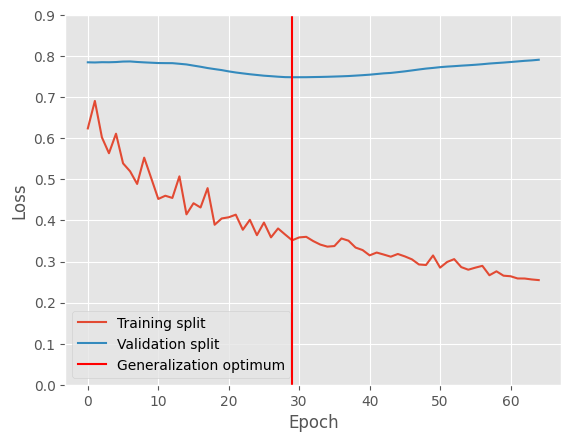

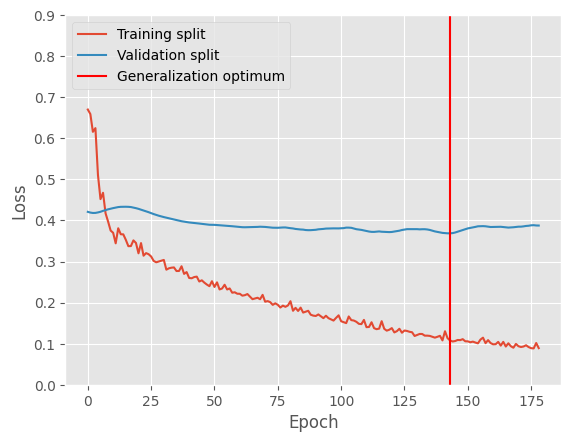

----------------------------------------------------
accuracy on training using syntax features
0.96
----------------------------------------------------
----------------------------------------------------
accuracy on test using syntax features
0.594
----------------------------------------------------
----------------------------------------------------
precision, recall, fscore and auc on the test set
(0.5654596100278552, 0.812, 0.6666666666666666, 0.5940000000000001)
----------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [149]:
for i in range(1):
    start = time.time()
    m3_syntax.weights_init_uniform()
    print('Training Model')  
    # m3_syntax.train()
    

    losses, val_losses = my_search_space_syn.train_model_cv(
                                                m3_syntax,
                                                train_embeddings=train_embeddings_syn,
                                                train_df=train_dfuch, 
                                                training_cpd=training_cpduch, 
                                                n_epochs=epochs_syntax,
                                                batch_size=batch_size_syn,
                                                optimizer=opt,
                                                lr=lr,
                                                verbose=True)
    
    debug('Showing training behavior for each fold', '')

    for fold_losses_train, fold_losses_val  in zip(losses, val_losses):
        plt.plot(fold_losses_train, label='Training split')
        plt.plot(fold_losses_val, label='Validation split')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.axvline(x=len(fold_losses_train) - 36, color='red', label='Generalization optimum')
        plt.legend()
        plt.yticks([0.1 * i for i in range(10)])
        plt.show()
        plt.clf()


    m3_syntax.eval()
    with torch.no_grad():
        y_preds_train_syn = my_search_space_syn.sequential_predict(m3_syntax,
                                            train_embeddings_syn,
                                            training_cpduch)
        #y_preds_train_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_train_syn]

        y_preds_test_syn = my_search_space_syn.sequential_predict(m3_syntax,
                                            test_embeddings_syn,
                                            test_cpduch)
    #y_preds_test_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_test_syn]
    a = my_search_space_syn.metrics(y_preds_train_syn, y_train)
    b = my_search_space_syn.metrics(y_preds_test_syn, y_test)
    debug(a[1], "accuracy on training using syntax features")
    debug(b[1], "accuracy on test using syntax features")
    debug(b[2], 'precision, recall, fscore and auc on the test set')


Training Model
------------------------------------------------------
training with cross-validation
--------------------------------------------------
------------------------------------------------------
------------------------------------------------------
epoch
0
------------------------------------------------------
------------------------------------------------------
epoch
20
------------------------------------------------------
------------------------------------------------------
epoch
40
------------------------------------------------------
------------------------------------------------------
epoch
60
------------------------------------------------------
------------------------------------------------------
epoch
0
------------------------------------------------------
------------------------------------------------------
epoch
20
------------------------------------------------------
----------------------------------------------------

Showing training behavior f

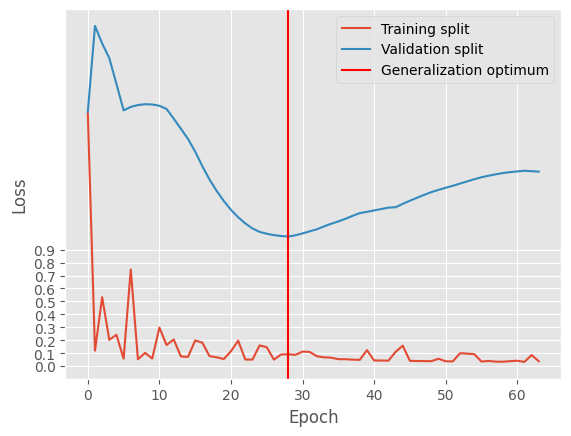

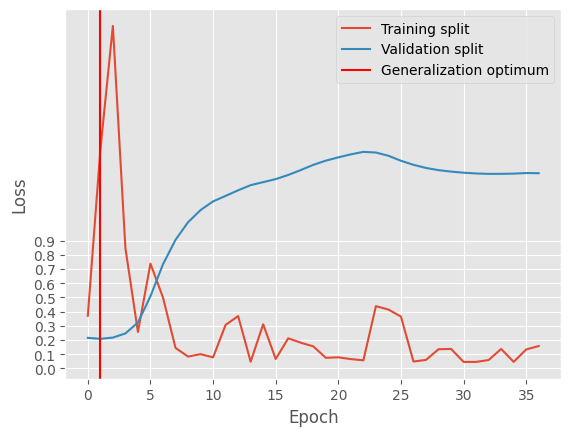

----------------------------------------------------
accuracy on training using semantic features
0.8
----------------------------------------------------
----------------------------------------------------
accuracy on test using semantic features
0.5333333333333333
----------------------------------------------------
----------------------------------------------------
precision, recall, fscore and auc on the test set
(0.5, 0.5714285714285714, 0.5333333333333333, 0.5357142857142857)
----------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [43]:
for i in range(1):
    start = time.time()
    m3_semantic.weights_init_uniform()
    print('Training Model')  
    # For when using onehot rnn, the dfs are the trains in format and test in format
    m3_semantic.train()

    losses, val_losses = my_search_space_sem.train_model_cv(
                                                m3_semantic,
                                                train_embeddings=train_embeddings_sem,
                                                train_df=train_dfuch, 
                                                training_cpd=training_cpduch, 
                                                n_epochs=epochs_semantic,
                                                batch_size=batch_size_sem,
                                                optimizer=opt,
                                                lr=lr,
                                                verbose=False)
    
    debug('Showing training behavior for each fold', '')
    for fold_losses_train, fold_losses_val  in zip(losses, val_losses):
        plt.plot(fold_losses_train, label='Training split')
        plt.plot(fold_losses_val, label='Validation split')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.axvline(x=len(fold_losses_train) - 36, color='red', label='Generalization optimum')
        plt.legend()
        plt.yticks([0.1 * i for i in range(10)])
        plt.show()
        plt.clf()


    m3_semantic.eval()

    with torch.no_grad():
        y_preds_train_sem = my_search_space_sem.sequential_predict(m3_semantic,
                                            train_embeddings_sem,
                                            training_cpduch)
        #y_preds_train_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_train_syn]

        y_preds_test_sem = my_search_space_sem.sequential_predict(m3_semantic,
                                            test_embeddings_sem,
                                            test_cpduch)
    #y_preds_test_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_test_syn]

    a = my_search_space_sem.metrics(y_preds_train_sem, y_train)
    b = my_search_space_sem.metrics(y_preds_test_sem, y_test)
    debug(a[1], "accuracy on training using semantic features")
    debug(b[1], "accuracy on test using semantic features")
    debug(b[2], 'precision, recall, fscore and auc on the test set')

### Partial training

Training Model
------------------------------------------------------

--------------------------------------------------
------------------------------------------------------
------------------------------------------------------
epoch
0
------------------------------------------------------
----------------------------------------------------

Showing training behavior
----------------------------------------------------


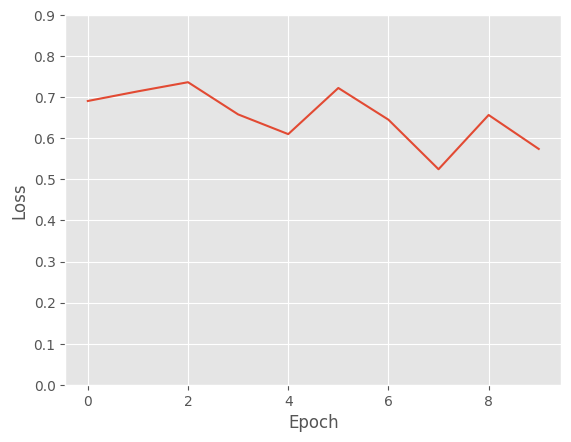

----------------------------------------------------
accuracy syntax training, acc syntax test, rest test
(0.7, 0.5666666666666667, (0.5238095238095238, 0.7857142857142857, 0.6285714285714286, 0.5803571428571428))
----------------------------------------------------


In [44]:
for i in range(1):
    start = time.time()
    m3_syntax.weights_init_uniform()
    print('Training Model')  
    # For when using onehot rnn, the dfs are the trains in format and test in format
    m3_syntax.train()
    

    losses, val_losses = my_search_space_syn.train_model(
                                                m3_syntax,
                                                train_embeddings=train_embeddings_syn,
                                                train_df=train_dfuch, 
                                                training_cpd=training_cpduch, 
                                                n_epochs=10,
                                                batch_size=batch_size_syn,
                                                optimizer=opt,
                                                lr=lr,
                                                verbose=False)
    

    
    debug('Showing training behavior', '')
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yticks([0.1 * i for i in range(10)])
    plt.show()


    m3_syntax.eval()
    with torch.no_grad():
        y_preds_train_syn = my_search_space_syn.sequential_predict(m3_syntax,
                                            train_embeddings_syn,
                                            training_cpduch)
        #y_preds_train_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_train_syn]

        y_preds_test_syn = my_search_space_syn.sequential_predict(m3_syntax,
                                            test_embeddings_syn,
                                            test_cpduch)
    #y_preds_test_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_test_syn]
    a = my_search_space_syn.metrics(y_preds_train_syn, y_train)
    b = my_search_space_syn.metrics(y_preds_test_syn, y_test)
    debug((a[1], b[1], b[2]), 'accuracy syntax training, acc syntax test, rest test')


Training Model
------------------------------------------------------

--------------------------------------------------
------------------------------------------------------
------------------------------------------------------
epoch
0
------------------------------------------------------


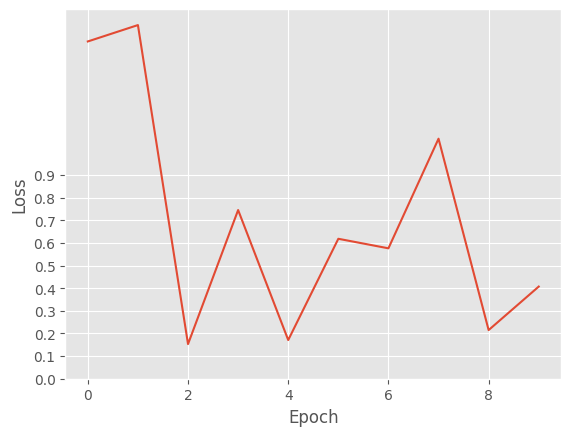

----------------------------------------------------
accuracy semantic training, acc semantic test, rest test
(0.6, 0.7, (0.8571428571428571, 0.42857142857142855, 0.5714285714285714, 0.6830357142857143))
----------------------------------------------------


In [45]:
for i in range(1):
    start = time.time()
    m3_semantic.weights_init_uniform()
    print('Training Model')  
    # For when using onehot rnn, the dfs are the trains in format and test in format
    m3_semantic.train()

    losses, val_losses = my_search_space_sem.train_model(
                                                m3_semantic,
                                                train_embeddings=train_embeddings_sem,
                                                train_df=train_dfuch, 
                                                training_cpd=training_cpduch, 
                                                n_epochs=10,
                                                batch_size=batch_size_sem,
                                                optimizer=opt,
                                                lr=lr,
                                                verbose=False)
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yticks([0.1 * i for i in range(10)])
    plt.show()
    

    # for fold_losses_train, fold_losses_val  in zip(losses, val_losses):
    #     plt.plot(fold_losses_train, label='training split')
    #     plt.plot(fold_losses_val, label='validation split')
    #     plt.show()
    #     plt.clf()


    m3_semantic.eval()

    with torch.no_grad():
        y_preds_train_sem = my_search_space_sem.sequential_predict(m3_semantic,
                                            train_embeddings_sem,
                                            training_cpduch)
        #y_preds_train_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_train_syn]

        y_preds_test_sem = my_search_space_sem.sequential_predict(m3_semantic,
                                            test_embeddings_sem,
                                            test_cpduch)
    #y_preds_test_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_test_syn]

    a = my_search_space_sem.metrics(y_preds_train_sem, y_train)
    b = my_search_space_sem.metrics(y_preds_test_sem, y_test)
    debug((a[1], b[1], b[2]), 'accuracy semantic training, acc semantic test, rest test')


## The evolutionary algorithm

In [46]:
class TrainingType(Enum):
    """ Enum to indicate the training type."""
    FULL = 'Full'
    PARTIAL = 'Partial'

In [47]:

def train_predict(model,
                  features_train, 
                  features_test,
                  train_df,
                  training_cpd,
                  test_cpd,
                  epochs,
                  batch_size,
                  lr,
                  opt,
                  search_space,
                  tt):
    """ Function that combines training and prediction on both sets.
    
    Input:
    ...
    tt: TrainingType -> The type of training to carry out. 

    Returns:
    y_preds_train: list[float] -> The predictions on the training set.
    y_preds_test: list[float] -> The predictions on the test set.
    elapsed: float -> The time taken to train in seconds.
    """
    
    model.weights_init_uniform()
    start = time.time()

    if tt == TrainingType.FULL:
        _, _ = search_space.train_model_cv(model,
                                        train_embeddings=features_train, 
                                        train_df=train_df, 
                                        training_cpd=training_cpd,
                                        n_epochs=epochs,
                                        batch_size=batch_size,
                                        optimizer=opt,
                                        lr=lr,
                                        verbose=False)
    elif tt == TrainingType.PARTIAL:
        _, _ = search_space.train_model(model,
                                        train_embeddings=features_train, 
                                        train_df=train_df, 
                                        training_cpd=training_cpd,
                                        n_epochs=epochs,
                                        batch_size=batch_size,
                                        optimizer=opt,
                                        lr=lr,
                                        verbose=False)
    model.eval()
    elapsed = time.time() - start
    with torch.no_grad():
        if isinstance(search_space, Sequential_Search_Space):
            y_preds_train = search_space.sequential_predict(model,
                                        features_train,
                                        training_cpd,)
            y_preds_test = search_space.sequential_predict(model,
                                        features_test,
                                        test_cpd,)
        elif isinstance(search_space, Graph_Search_Space):
            y_preds_train = search_space.graph_predict(model,
                                        features_train,
                                        training_cpd,)
            y_preds_test = search_space.graph_predict(model,
                                        features_test,
                                        test_cpd,)

    return y_preds_train, y_preds_test, elapsed

In [48]:

def train_predict_evaluate(curr_enc, search_space, udd, tt=TrainingType.PARTIAL):
    """ Function to train, predict and evaluate all at once.
    
    Input:
    curr_enc: list[int] -> The encoding of the DNN.
    search_space: Search_Space -> The search space instance.
    udd: dict -> A useful data dictionary, with training hyperparameters.
    tt: TrainingType -> The type of training.csv

    Returns:
    new_row: DataFrame -> A DataFrame row containing the encoding and its 
                          corresponding performance measurements.

    """

    curr_es = ','.join([str(gene) for gene in curr_enc])
    try:
        # Not meant for ensemble.
        #debug('sequential search space', None)
        if isinstance(search_space, Sequential_Search_Space):
            model = Model(curr_enc, 
                        search_space.input_shape, 
                        search_space.genel,
                        search_space.input_shape // 2)
        elif isinstance(search_space, Graph_Search_Space):
            model = Model_FG(curr_enc, 
                        search_space.input_shape, 
                        search_space.genel,
                        search_space.input_shape // 2)            
        #debug(model, 'model created')
        y_preds_train, y_preds_test, elapsed = train_predict(model, 
                                        udd['features_train'],
                                        udd['features_test'],
                                        udd['train_df'],
                                        udd['training_cpd'],
                                        udd['test_cpd'],
                                        udd['epochs'],
                                        udd['batch_size'],
                                        udd['lr'],
                                        udd['opt'],
                                        search_space,
                                        tt)

        _, curr_acc_train, (_, _, _, curr_auctr) = search_space.metrics(y_preds_train, udd['y_train'])

        _, curr_acc_test, (curr_precte, curr_recte, curr_fscorete, curr_aucte) = search_space.metrics(y_preds_test, udd['y_test'])
        curr_acc = curr_aucte * 0.75 + curr_auctr * 0.25
    except Exception as e:
        print(e)
        curr_acc_train, curr_acc_test = 0, 0
        curr_precte, curr_recte, curr_fscorete, curr_aucte = 0, 0, 0, 0
        curr_acc = 0
        elapsed = 0

    new_row = pd.DataFrame()
    new_row['encoding'] = [curr_es]
    new_row['test accuracy'] = [curr_acc_test]
    new_row['training accuracy'] = [curr_acc_train]
    new_row['combined accuracy'] = [curr_acc]
    new_row['test precision'] = [curr_precte]
    new_row['test recall'] = [curr_recte]
    new_row['test fscore'] = [curr_fscorete]
    new_row['test auc'] = [curr_aucte]
    new_row['training time'] = [elapsed]

    return new_row

In [49]:

def initialize_random_perms(ps, search_space):
    """ Initialize a random population.
    
    Input:
    ps: int -> The population size.
    search_space -> Search_Space -> A search space instance.

    Returns:
    P: list[int] -> The initial population.
    """

    P = []
    for x in range(ps):
        valid = False

        while not valid:
            new_born = []
            for i in range(search_space.encoding_size):            
                if isinstance(search_space, Sequential_Search_Space):
                    new_born += [random.choice(list(range(len(search_space.model.int_to_mod))))]
                elif isinstance(search_space, Graph_Search_Space):
                    new_born += [random.choice([0, 1])]
            valid = search_space.feasible(new_born)
        P += [new_born]
    return P

In [50]:
def get_surrogate_df():
    """ Function to load the surrogate df at this point in time."""

    if os.path.exists('surrogateDF.csv'):
        surrogate_df = pd.read_csv('surrogateDF.csv', 
                                dtype={'encoding': str, 
                                'test accuracy': np.float64, 
                                'training accuracy': np.float64, 
                                'combined accuracy': np.float64,
                                'test precision': np.float64,
                                'test recall': np.float64,
                                'test fscore': np.float64})
    else:
        surrogate_df = pd.DataFrame(columns = ['encoding', 
                                            'test accuracy', 
                                            'training accuracy', 
                                            'combined accuracy',
                                            'test precision',
                                            'test recall',
                                            'test fscore'])
    return surrogate_df

def get_no_improvement_df():
    """ Function to load the no improvement df at this point in time."""

    if os.path.exists('noImprovementDF.csv'):
        no_improvement_df = pd.read_csv('noImprovementDF.csv', 
                                dtype={'encoding': str, 
                                'test accuracy': np.float64, 
                                'training accuracy': np.float64, 
                                'combined accuracy': np.float64,
                                'test precision': np.float64,
                                'test recall': np.float64,
                                'test fscore': np.float64})
    else:
        no_improvement_df = pd.DataFrame(columns = ['encoding', 
                                            'test accuracy', 
                                            'training accuracy', 
                                            'combined accuracy',
                                            'test precision',
                                            'test recall',
                                            'test fscore'])
    return no_improvement_df

def get_convergence_df():
    """ Function to load the convergence df at this point in time."""

    if os.path.exists('convergenceDF.csv'):
        convergence_df = pd.read_csv('convergenceDF.csv', 
                                dtype={'fitness': np.float64,
                                        'encoding': str})
    else:
        convergence_df = pd.DataFrame(columns = ['fitness',
                                           'encoding'])
    return convergence_df

def get_best_models_scores(ps, 
                           udd,
                           search_space):
    """ Function to get the fitness measurements for the latest population.
    
    Input:
    ps: int -> population size.
    udd: dict -> a useful data dictionary, with information about the training.
    search_space: Search_Space -> The search space instance.

    Returns:
    best_models_scores: list[float] -> The fitness values for the latest
                                       population.
    """

    surrogate_df = get_surrogate_df()
    len_sdf = len(surrogate_df)
    if len_sdf < ps:
        debug('Getting initial population', '')
        initial_P = initialize_random_perms(ps, search_space)
        debug(initial_P, 'initial P')
        #debug(len(initial_P[0]), 'initial P')
        
        for curr_enc in (initial_P):
            new_row = train_predict_evaluate(curr_enc, search_space, udd)
            print("new row", new_row)

            surrogate_df = pd.concat([surrogate_df, new_row])
            surrogate_df.to_csv('surrogateDF.csv', index=False)
    best_models_scores = list(zip(surrogate_df[:ps]['combined accuracy'],
                                  surrogate_df[:ps]['encoding']))
    return best_models_scores



In [51]:
class Encoding(Enum):
    """ Enum to indicate the encoding type."""

    PERMUTATION = "PERMUTATION"
    BINARY = 'BINARY'

class Selection(Enum):
    """ Enum to indicate the selection type."""

    TOURNEY = "TOURNEY"

def binary_tourney(f_P, q):
    """ Randomly compare two fitnesses, and return index of the winner.
    
    Input:
    f_P: list[float] -> Fitnesses for the population
    q: int -> Number of contestants
    
    Output:
    int -> The index of the winner.
    """

    contestants = random.sample(f_P, q)
    winner = max(contestants)
    return f_P.index(winner)

def diff_bin_crossover(n, pr):
    """ It calculates positions where the parent will exchange genes.
    
    Input: 
    n: int -> The number of variables (genes)
    pr: float -> probability that any position is added to the result.

    Returns:
    J: set -> A set of positions where the parent will exchange genes.
    """
    
    jstar = random.randint(0, n - 1) #0-indexed
    #debug(jstar, 'jstar')
    J = {jstar}
    for j in range(0, n):
        if random.random() < pr and j != jstar:
            J = J.union({j})
    return J

def spx(parents):
    """Single point crossover
    At this point the crossover has been determined
    """

    P0, P1 = parents
    child1, child2 = P0, P1
    ilen = len(P0)
    ws = [1 / (ilen - 1)] * (ilen - 1)
    position = random.choices(list(range(ilen - 1)), weights=ws, k=1)[0]
    left1 = P0[: position + 1]  # exclusive upper limit
    left2 = P1[: position + 1]
    right1 = P0[position + 1 :]
    right2 = P1[position + 1 :]
    child1 = left1 + right2
    child2 = left2 + right1
    return (child1, child2)

def mutate(encoding, search_space):
    """ Function to mutate an encoding.
    
    Input:
    encoding: list[int] -> The encoding that represents the model.
    search_space: Search_Space -> The search space instance.
    
    Returns:
    new_enc: list[int] -> The mutated encoding.
    """
    
    diff_vals = False
    while not diff_vals:
        i1 = random.choice(list(range(len(encoding))))
        if isinstance(search_space, Sequential_Search_Space):
            v = random.choice(list(range(len(search_space.model.int_to_mod))))
        elif isinstance(search_space, Graph_Search_Space):
            v = 1 - encoding[i1]
        if encoding[i1] != v:
            diff_vals = True
    
    new_enc = encoding.copy()
    new_enc[i1] = v
    #print(f"new encoding {new_enc}")

    return new_enc

Example of the mutation

In [52]:
mutate(encoding_se, my_search_space_sem)

[16, 10, 16, 9, 2, 18, 19, 12, 11, 8, 23, 10, 9, 5, 11]

In [53]:
# mutate([0] * 15, my_search_space_graph)

In [54]:


def genetic_algorithm(
    search_space,
    encoding,
    selection,
    udd,
    n=0,
    ps=100,
    prob_c=0.9,
    prob_c_bin=0.9,
    prob_m=0.001,
    iterations=100,
    verbose=False,
    problem="?",
):
    """ An evolutionary algorithm, derived from the genetic algorithm.

    Input:
    search_space: Search_Space -> The search space instance.
    encoding: Encoding -> The encoding type of the DNNs. 
    selection: Selection -> type of selection enumerator.
    n: int -> number of variables
    ps: int -> population size
    prob_c: float -> probability for crossover event.
    prob_c_bin: float -> probability for binomial crossover.
    prob_m: float -> probability for mutation event.
    iterations: int -> the number of iterations. If the algorithm is used the 
                       first time, the number of iterations does not include,
                       the first iteration (e.g. with value 49, plust the first
                       iteration, it will run for 50 iterations).
    verbose: bool -> To debug the intermediate steps of the algorithm

    Returns:
    None (The results of measurement and convergence are saved in csvs)
    """

    if verbose:
        debug(f"{encoding.value} and {selection.value}", "RUNNING GENETIC ALGORITHM")

    # Initialize Population
    # PERMUTATION ENCODING ONLY
    best_models_scores = get_best_models_scores(ps=ps, udd=udd, search_space=search_space)
    debug(best_models_scores, 'Before generations')
    

    surrogate_df = get_surrogate_df()
    evaluated = set(surrogate_df['encoding'])

    P = [encoding for score, encoding in best_models_scores]
    
    # Fitness P
    f_P = [score for score, encoding in best_models_scores]
    all_vars = P
    if verbose:
        debug(P, "Initial population")

    convergence_df = get_convergence_df()
    if len(convergence_df) == 0:
        new_row = pd.DataFrame()
        new_row['fitness'] = [max(f_P)]
        new_row['encoding'] = [all_vars[f_P.index(max(f_P))]]
        convergence_df = pd.concat([convergence_df, new_row])
        convergence_df.to_csv('convergenceDF.csv', index=False)

    if verbose:
        debug(f_P, "Fitnesses")

    t = 0
    for i in range(iterations):
        evaluated = set(surrogate_df['encoding'])
        if verbose:
            debug("", f"GENERATION {i}")
        children = []
        # Number of times to get 2 children to equal population size.
        for j in range(ps // 2):
            if verbose:
                debug(selection, "SELECTION HAPPENNING")
            '''if selection == Selection.ROULETTE:
                P1_ind = roulette(f_Pa)
                P2_ind = roulette(f_Pa)'''
            if selection == Selection.TOURNEY:
                P1_ind = binary_tourney(f_P, q=2)
                P2_ind = binary_tourney(f_P, q=2)
            '''elif selection == Selection.RANDOM:
                P1_ind = random_selection(f_P)
                P2_ind = random_selection(f_P)'''
            if verbose:
                debug((P1_ind, P2_ind), "Selected parents positions")
                debug(P[P1_ind], 'parent 1')
                debug(P[P2_ind], 'parent 2')
            
            P1 = Model.encoding_str2list(P[P1_ind])
            P2 = Model.encoding_str2list(P[P2_ind])
            if verbose:
                debug((P1, P2), "Selected parents")

            if random.random() <= prob_c:
                if verbose:
                    debug("", "CROSSOVER HAPPENNING")
                # Crossover with crossover probability.
                
                if encoding == Encoding.PERMUTATION:
                    # PERMUTATION ENCODING
                    # Crossover indices.
                    crinds = diff_bin_crossover(n, prob_c_bin)
                    H1 = P1
                    H2 = P2
                    
                    for crind in crinds:
                        H1[crind] = P2[crind]
                        H2[crind] = P1[crind]

                    
                elif encoding == Encoding.BINARY:
                    H1, H2 = spx((P1, P2))

                children += [H1, H2]
            else:
                # No crossover.
                children += [P1, P2]
            if verbose:
                ...#debug(children, "Children")

        # Mutation with mutation probability.
        # child index.
        for cind, child in enumerate(children):

            if random.random() <= prob_m:
                if verbose:
                    debug("", "MUTATION HAPPENNING")
                    debug(child, "Before mutate")
                
                child = mutate(child, search_space=search_space)
                if verbose:
                    debug(child, "After mutate")
            
            old_child1 = ','.join([str(gene) for gene in child]) in evaluated 
            old_child2 = not search_space.feasible(child)
            old_child = old_child1 or old_child2
            if verbose:
                debug(','.join([str(gene) for gene in child]), 'string child')
                debug(old_child, 'old child result')
                debug(old_child1, 'in evaluated result')
            while old_child:
                if verbose:
                    debug("", "child is old")
                    debug(child, "Before mutate")
                new = []
                for j in range(n):
                    if isinstance(search_space, Sequential_Search_Space):
                        new += [random.randint(0, len(search_space.model.int_to_mod) - 1)]
                    elif isinstance(search_space, Graph_Search_Space):
                        new += [random.randint(0, 1)]
                #new += [random.randint(0, 2000), random.randint(0, 1)]
                child = new#mutate(child, search_space=search_space)
                old_child = ','.join([str(gene) for gene in child]) in evaluated or not search_space.feasible(child)
                if verbose:
                    debug(child, "After mutate")
            children[cind] = child
            
            evaluated.add(','.join([str(gene) for gene in child]))
                    
        debug(children, 'children ready')
        for child in children:  
            debug(child, 'evaluating child')
            new_row = train_predict_evaluate(child, search_space, udd)

            surrogate_df = pd.concat([surrogate_df, new_row])
        surrogate_df.sort_values('combined accuracy', ascending=False, inplace=True)
        surrogate_df.to_csv('surrogateDF.csv', index=False)
        #evaluated = set(surrogate_df['encoding'])
        if verbose:
            debug(evaluated, 'evaluated')

        best_models_scores = get_best_models_scores(ps=ps, udd=udd, search_space=search_space)
        debug(best_models_scores, f'generation {i}')

        P = [encoding for score, encoding in best_models_scores]
    
        # REAL
        # Fitness P
        f_P = [score for score, encoding in best_models_scores]
        all_vars = P

        new_row = pd.DataFrame()
        new_row['fitness'] = [max(f_P)]
        new_row['encoding'] = [all_vars[f_P.index(max(f_P))]]
        convergence_df = pd.concat([convergence_df, new_row])
        convergence_df.to_csv('convergenceDF.csv', index=False)

        if verbose:
            debug(all_vars[f_P.index(max(f_P))], "best variables")
            debug(f_P, "Fitnesses")

        t += 1
        torch.cuda.empty_cache()

Setting up for the evolutionary algorithm

In [55]:

batch_size = 4
epochs_partial = 10
lr = 0.001
opt = 'Adam'

population_s = 24
n=15
prob_c=0.9
prob_c_bin=0.7
prob_m=1 / 15
iterations = 9 # In the thesis we used 49 iterations, we do 9 just to show the example.
nas_runs = 2

udd_syntax = {'features_train': train_embeddings_syn, 
        'features_test': test_embeddings_syn,
        'train_df': train_dfuch,
        'training_cpd': training_cpduch,
        'test_cpd': test_cpduch,
        'y_train': y_train,
        'y_test': y_test,
        'epochs': epochs_partial,
        'batch_size': batch_size,
        'lr': lr,
        'opt': opt,}


udd_semantic = {'features_train': train_embeddings_sem, 
        'features_test': test_embeddings_sem,
        'train_df': train_dfuch,
        'training_cpd': training_cpduch,
        'test_cpd': test_cpduch,
        'y_train': y_train,
        'y_test': y_test,
        'epochs': epochs_partial,
        'batch_size': batch_size,
        'lr': lr,
        'opt': opt,}


We execute the experiments for the selected dataset, a number of _nas_runs_ times, for models using both syntactic features and semantic features. Convergence and measurements results saved in _surrogates_ folder. 

In [56]:
for i in range(nas_runs):
    genetic_algorithm(my_search_space_syn, 
                Encoding.PERMUTATION, 
                Selection.TOURNEY, 
                udd_syntax,
                n=n,
                ps=population_s, 
                prob_c=prob_c,
                prob_c_bin=prob_c_bin,
                prob_m=prob_m,
                iterations=iterations,
                verbose=False)
    shutil.move(
    "surrogateDF.csv", os.path.join("surrogates", "synBetter", f"surrogateDF{i + 1}.csv")
    )
    shutil.move(
        "convergenceDF.csv",
        os.path.join("surrogates", "synBetter", f"convergenceDF{i + 1}.csv"),
    )

for i in range(nas_runs):
    genetic_algorithm(my_search_space_sem, 
                Encoding.PERMUTATION, 
                Selection.TOURNEY, 
                udd_semantic,
                n=n,
                ps=population_s, 
                prob_c=prob_c,
                prob_c_bin=prob_c_bin,
                prob_m=prob_m,
                iterations=iterations,
                verbose=False)
    shutil.move(
    "surrogateDF.csv", os.path.join("surrogates", "sem", f"surrogateDF{i + 1}.csv")
    )
    shutil.move(
        "convergenceDF.csv",
        os.path.join("surrogates", "sem", f"convergenceDF{i + 1}.csv"),
    )
    

----------------------------------------------------

Getting initial population
----------------------------------------------------
----------------------------------------------------
initial P
[[5, 0, 13, 13, 2, 3, 4, 10, 15, 18, 14, 13, 6, 6, 10], [6, 3, 2, 6, 8, 22, 9, 9, 22, 8, 5, 19, 3, 0, 8], [18, 13, 11, 7, 3, 19, 1, 16, 6, 13, 5, 5, 2, 3, 9], [13, 8, 3, 12, 3, 6, 7, 6, 7, 3, 9, 4, 17, 12, 4], [20, 2, 14, 15, 0, 5, 6, 20, 9, 12, 3, 9, 6, 11, 19], [18, 15, 10, 7, 6, 9, 14, 10, 12, 6, 19, 1, 11, 4, 2], [16, 4, 0, 7, 13, 16, 14, 7, 12, 12, 22, 17, 22, 9, 16], [3, 23, 8, 20, 1, 16, 6, 11, 12, 6, 17, 16, 22, 9, 15], [2, 4, 8, 8, 3, 4, 9, 2, 15, 1, 16, 1, 15, 15, 12], [21, 16, 15, 4, 5, 6, 6, 9, 3, 6, 14, 12, 14, 2, 9], [16, 7, 23, 5, 17, 18, 11, 9, 4, 0, 10, 12, 4, 9, 16], [23, 4, 16, 2, 5, 19, 16, 16, 1, 3, 8, 13, 18, 2, 17], [14, 13, 10, 7, 17, 23, 5, 16, 1, 14, 2, 16, 0, 9, 0], [3, 23, 1, 11, 5, 21, 6, 5, 7, 9, 0, 3, 1, 7, 13], [2, 16, 16, 16, 15, 5, 4, 6, 17, 11, 4, 4, 9, 3, 5

## Population evaluation full training

This following section was used to apply full training to the most promising DNNs found with NAS after partial training.

In [57]:
max_epochs = 200

udd_syntax = {'features_train': train_embeddings_syn, 
        'features_test': test_embeddings_syn,
        'train_df': train_dfuch,
        'training_cpd': training_cpduch,
        'test_cpd': test_cpduch,
        'y_train': y_train,
        'y_test': y_test,
        'epochs': max_epochs,
        'batch_size': batch_size,
        'lr': lr,
        'opt': opt,}


udd_semantic = {'features_train': train_embeddings_sem, 
        'features_test': test_embeddings_sem,
        'train_df': train_dfuch,
        'training_cpd': training_cpduch,
        'test_cpd': test_cpduch,
        'y_train': y_train,
        'y_test': y_test,
        'epochs': max_epochs,
        'batch_size': batch_size,
        'lr': lr,
        'opt': opt,}

Here we apply full training to the top population of all the executions of the evolutionary algorithm, which were originally partially trained.

In [58]:
# Measurements full df
mea_full_df_syn = pd.DataFrame(columns=["encoding"])

for filenm in os.listdir(os.path.join('surrogates', 'synBetter')):

    if 'surrogate' in filenm:

        bpop = pd.read_csv(os.path.join('surrogates', 'synBetter', filenm))['encoding'][:population_s]

        for enc in bpop:
            if enc not in mea_full_df_syn['encoding'].values:
                curr_enc = Model.encoding_str2list(enc)
                mea_row = train_predict_evaluate(curr_enc, 
                                                 my_search_space_syn, 
                                                 udd_syntax,
                                                 tt=TrainingType.FULL)
                mea_full_df_syn = pd.concat([mea_full_df_syn, mea_row])


----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): RDropout()
  (1): ReLU()
  (2): Identity()
  (3): Linear(in_features=970, out_features=4096, bias=True)
  (4): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Linear(in_features=4096, out_features=512, bias=True)
  (7): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): Linear(in_features=512, out_features=16, bias=True)
  (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): Linear(in_features=16, out_features=4, bias=True)
  (11): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): Linear(in_features=4, out_features=16, bias=True)
  (13): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): Conv1d(1, 8, kernel_size=(8,), stride=(1,))
  (15): Flatten(start_dim=1, end_dim=-1)
  (16): BatchNorm1

After the full training, we sort by the combined accuracy, which is the fitness, and visualize the top 15. We originally used the accuracies in training/test, but then we decided to use the AUC measures, since these can be useful even when the data is imbalanced.

In [59]:
mea_full_df_syn.sort_values('combined accuracy', ascending=False, inplace=True)
mea_full_df_syn[:15]

,encoding,test accuracy,training accuracy,combined accuracy,test precision,test recall,test fscore,test auc,training time
0,"16,14,1,7,3,21,0,4,2,7,12,16,0,17,10",0.733333,0.5,0.680804,0.666667,0.857143,0.750000,0.741071,1.538793
0,"0,11,18,16,5,23,14,16,0,19,14,17,15,19,14",0.600000,0.9,0.670312,0.583333,0.500000,0.538462,0.593750,2.063474
0,"17,5,19,2,15,13,13,21,7,13,0,17,22,1,8",0.600000,0.8,0.648661,0.571429,0.571429,0.571429,0.598214,8.197036
0,"4,16,11,9,11,23,0,8,22,0,14,0,10,9,22",0.700000,0.5,0.647321,0.692308,0.642857,0.666667,0.696429,1.571990
0,"14,14,13,10,6,11,2,2,19,12,15,13,6,4,14",0.700000,0.5,0.643973,0.727273,0.571429,0.640000,0.691964,2.012540
0,"5,4,0,19,4,16,4,10,15,18,0,13,6,6,10",0.566667,0.8,0.638616,0.521739,0.857143,0.648649,0.584821,2.517739
0,"10,23,17,2,6,2,14,15,15,9,16,5,6,4,1",0.600000,0.7,0.627009,0.562500,0.642857,0.600000,0.602679,2.277832
0,"5,4,13,13,2,3,4,10,11,18,14,13,6,9,10",0.600000,0.6,0.595313,0.583333,0.500000,0.538462,0.593750,1.252853
0,"10,23,11,2,2,19,12,15,5,8,4,2,22,4,1",0.633333,0.4,0.592187,0.560000,1.000000,0.717949,0.656250,1.337030
0,"17,14,5,4,4,18,3,0,15,20,8,9,8,20,9",0.666667,0.4,0.592187,0.700000,0.500000,0.583333,0.656250,1.475474


We save the results in a csv file.

In [60]:
mea_full_df_syn.to_csv('surrogateFTDFSyntax.csv')

We will repeat the process for models trained with semantic features.

In [ ]:
# Measurements full df
mea_full_df_sem = pd.DataFrame(columns=["encoding"])

for filenm in os.listdir(os.path.join('surrogates', 'sem')):

    if 'surrogate' in filenm:
        bpop = pd.read_csv(os.path.join('surrogates', 'sem', filenm))['encoding'][:population_s]


        for enc in bpop:
            debug(enc, 'encoding')
            if enc not in mea_full_df_sem['encoding'].values:
                curr_enc = Model.encoding_str2list(enc)
                mea_row = train_predict_evaluate(curr_enc,
                                                 my_search_space_sem,
                                                 udd_semantic,
                                                 tt=TrainingType.FULL)
                mea_full_df_sem = pd.concat([mea_full_df_sem, mea_row])

----------------------------------------------------
encoding
9,6,16,9,13,15,3,11,16,7,23,5,17,18,11
----------------------------------------------------
----------------------------------------------------
encoding is new ish
9,6,16,9,13,15,3,11,16,7,23,5,17,18,11
----------------------------------------------------
----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Linear(in_features=600, out_features=4, bias=True)
  (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Linear(in_features=4, out_features=512, bias=True)
  (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Linear(in_features=512, out_features=4, bias=True)
  (6): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Linear(in_features=4, out_features=64, bias=True)
  (8): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [62]:
mea_full_df_sem.sort_values('combined accuracy', ascending=False, inplace=True)
mea_full_df_sem[:15]


,encoding,test accuracy,training accuracy,combined accuracy,test precision,test recall,test fscore,test auc,training time
0,"8,20,3,7,1,5,1,3,8,9,4,16,3,9,19",0.633333,0.6,0.625446,0.600000,0.642857,0.620690,0.633929,1.575774
0,"16,15,5,4,6,17,11,4,4,9,3,5,17,9,14",0.566667,0.7,0.616964,0.520000,0.928571,0.666667,0.589286,1.226168
0,"8,22,15,14,9,1,0,1,2,0,16,9,13,8,14",0.633333,0.6,0.615402,0.666667,0.428571,0.521739,0.620536,1.695253
0,"9,15,15,14,6,1,0,1,2,0,16,5,17,8,14",0.600000,0.5,0.556920,0.750000,0.214286,0.333333,0.575893,1.617074
0,"10,2,3,15,4,18,8,10,15,20,7,9,8,20,8",0.566667,0.5,0.553571,0.529412,0.642857,0.580645,0.571429,6.729010
0,"17,14,5,4,4,18,3,0,15,20,8,9,8,20,9",0.533333,0.5,0.546875,0.500000,1.000000,0.666667,0.562500,1.448157
0,"14,12,19,6,1,1,13,1,18,8,16,1,18,16,5",0.500000,0.7,0.546652,0.461538,0.428571,0.444444,0.495536,1.968667
0,"3,22,2,7,8,18,14,14,15,1,1,20,14,2,5",0.566667,0.5,0.526786,1.000000,0.071429,0.133333,0.535714,1.624736
0,"0,19,4,16,11,9,11,23,0,8,22,0,14,0,10",0.533333,0.6,0.525000,0.000000,0.000000,0.000000,0.500000,1.803257
0,"9,6,5,9,13,15,8,11,16,7,8,5,17,18,11",0.533333,0.5,0.516741,0.500000,0.357143,0.416667,0.522321,1.683367


In [63]:
mea_full_df_sem.to_csv('surrogateFTDFSemantic.csv')

## Seed Robustness evaluation

We will test the robustness of multiple models to the weight initialization seed.

In [64]:
encodings_sy = [[16,6,13,13,15,6,23,5,4,6,5,8,15,11,2],
                [16,6,13,13,4,6,23,5,4,6,5,8,15,11,2],
                [19,4,16,11,9,11,2,0,8,22,0,14,0,10,9],
                 [5,16,23,5,9,23,13,7,16,4,10,3,16,5,9],
                 [5,11,12,17,21,12,14,20,3,10,14,0,7,3,23],
                 [19,4,16,11,9,11,23,0,8,22,0,14,0,10,9],
                 [5,7,23,17,9,23,13,7,16,13,10,13,4,5,9],
                 ]

all_aucs = []
for enc_sy in encodings_sy:
    curr_aucs = []
    for i in range(1, 16):

        m3_syntax = Model(enc_sy, 
            syn_embsz * 2,#my_search_space.input_shape_syntax, 
            my_search_space_syn.genel,
            syn_embsz,
            i)

        m3_syntax.weights_init_uniform()
        print('Training Model')  
        # For when using onehot rnn, the dfs are the trains in format and test in format
        m3_syntax.train()

        train_losses, val_losses = my_search_space_syn.train_model_cv(
                                                    m3_syntax,
                                                    train_embeddings=train_embeddings_syn,
                                                    train_df=train_dfuch, 
                                                    training_cpd=training_cpduch, 
                                                    n_epochs=epochs_syntax,
                                                    batch_size=batch_size_syn,
                                                    optimizer=opt,
                                                    lr=lr,
                                                    verbose=False)
        
        # for fold_losses_train, fold_losses_val  in zip(train_losses, val_losses):
        #     plt.plot(fold_losses_train, label='Training split')
        #     plt.plot(fold_losses_val, label='Validation split')
        #     plt.xlabel('Epoch')
        #     plt.ylabel('Loss')
        #     plt.axvline(x=len(fold_losses_train) - 36, color='red', label='Generalization optimum')
        #     plt.legend()
        #     plt.yticks([0.1 * i for i in range(10)])
        #     plt.show()
        #     plt.clf()

        m3_syntax.eval()

        with torch.no_grad():
            y_preds_train_syn = my_search_space_syn.sequential_predict(m3_syntax,
                                                train_embeddings_syn,
                                                training_cpduch)
            #y_preds_train_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_train_syn]

            y_preds_test_syn = my_search_space_syn.sequential_predict(m3_syntax,
                                                test_embeddings_syn,
                                                test_cpduch)
        #y_preds_test_syn = [my_search_space_syn.logit2int(pred) for pred in y_preds_test_syn]

        a = my_search_space_syn.metrics(y_preds_train_syn, y_train)
        b = my_search_space_syn.metrics(y_preds_test_syn, y_test)
        debug((a[1], b[1], b[2]), 'accuracy syntax training, acc syntax test, rest test')
        curr_aucs += [b[2][3]]
    all_aucs += [curr_aucs]



----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Linear(in_features=970, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Linear(in_features=512, out_features=64, bias=True)
  (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Linear(in_features=64, out_features=64, bias=True)
  (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Linear(in_features=64, out_features=256, bias=True)
  (8): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Conv1d(1, 8, kernel_size=(8,), stride=(1,))
  (11): Flatten(start_dim=1, end_dim=-1)
  (12): BatchNorm1d(1992, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): Tanh()
  (14): ReLU()
  (15): LeakyReLU(negative_slope=0.0

For different seed multipliers, we visualize the performance of the top 7 models using syntactic features on the CLEF-PAN 2013 dataset after full training.

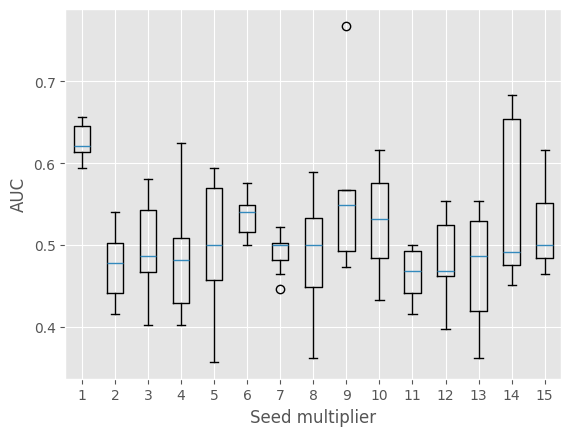

In [ ]:
all_aucs = np.array(all_aucs)
plt.figure(figsize=(10, 5))
plt.boxplot(all_aucs)
plt.ylabel('AUC')
plt.xlabel('Seed multiplier')
plt.savefig('seedSamples.png', dpi=200)


The p value tells us that the there is strong evidence against the null hypothesis. In this context, it tells us that there is significant difference in the median of the related groups being compared, and the difference stems from the seed multiplier.

In [66]:
from scipy.stats import friedmanchisquare

stat, p_value = friedmanchisquare(*(all_aucs[:, i] for i in range(all_aucs.shape[1])))
debug(p_value, 'p_value')

----------------------------------------------------
p_value
0.010445333069445228
----------------------------------------------------


## Hyperparameter tuning

We test the utility of random search hyperparameter tuning on the models that use syntactic features to solve the CLEF-PAN 2013 dataset.

In [89]:
def random_search_hyperparameter_tuning(encoding,
                                        num_trials=1, 
                                        log_dir="logs",):
    """Performs random search hyperparameter tuning with TensorBoard logging."""

    # Trials so far
    tsf = len(os.listdir(log_dir))

    best_auc = float('-inf')
    
    for trial in range(num_trials):
        random.seed(trial)
        batch_size_r = random.choice([2, 3, 4, 5])
        learning_rate_r = round(random.uniform(0.001, 0.003), 3)
        num_epochs_r= random.choice(range(200, 500))
        optimizer_name_r = random.choice(['Adam', 'AdamW', 'SGD'])
        
        print(f"Trial {trial + 1}/{num_trials}:")
        print(f"  Batch Size: {batch_size_r}")
        print(f"  Learning Rate: {learning_rate_r}")
        print(f"  Optimizer: {optimizer_name_r}")
        print(f"  Epochs: {num_epochs_r}")
        

        trial_log_dir = os.path.join(log_dir, f"Trial_{tsf + trial}")
        writer = SummaryWriter(trial_log_dir)

        udd_syntax_r = {'features_train': train_embeddings_syn, 
        'features_test': test_embeddings_syn,
        'train_df': train_dfuch,
        'training_cpd': training_cpduch,
        'test_cpd': test_cpduch,
        'y_train': y_train,
        'y_test': y_test,
        'epochs': num_epochs_r,
        'batch_size': batch_size_r,
        'lr': learning_rate_r,
        'opt': optimizer_name_r,}

        new_row = train_predict_evaluate(encoding, 
                               my_search_space_syn, 
                               udd_syntax_r,
                               tt=TrainingType.FULL)
        
        curr_auc = new_row['test auc'].values[0]

        if curr_auc > best_auc:
            best_params = (batch_size_r, 
                           learning_rate_r, 
                           num_epochs_r, 
                           optimizer_name_r)
            best_auc = curr_auc

        writer.add_hparams(hparam_dict={'batch_size': batch_size_r,
                            'learning_rate': learning_rate_r,
                            'optimizer': optimizer_name_r,
                            'num_epochs': num_epochs_r}, 
                            metric_dict={'test_precision': new_row['test precision'].values[0],
                                        'test_recall': new_row['test recall'].values[0],
                                        'test_fscore': new_row['test fscore'].values[0],
                                        'test_auc': curr_auc,
                                        'test_acc': new_row['test accuracy'].values[0],})
        writer.close()
    return best_params, best_auc


In [90]:

best_full_syntax_enc = [16,6,13,13,15,6,23,5,4,6,5,8,15,11,2]
best_params, best_auc = random_search_hyperparameter_tuning(best_full_syntax_enc,
                                    num_trials=50)

Trial 1/50:
  Batch Size: 5
  Learning Rate: 0.003
  Optimizer: Adam
  Epochs: 415
----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Linear(in_features=970, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Linear(in_features=512, out_features=64, bias=True)
  (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Linear(in_features=64, out_features=64, bias=True)
  (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Linear(in_features=64, out_features=256, bias=True)
  (8): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Conv1d(1, 8, kernel_size=(8,), stride=(1,))
  (11): Flatten(start_dim=1, end_dim=-1)
  (12): BatchNorm1d(1992, eps=1e-05, momentum=0.1, affine=True, track_run

In [91]:
best_params

(2, 0.003, 466, 'Adam')

In [92]:
best_auc

0.65625

In [93]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [94]:
%tensorboard --logdir logs

Reusing TensorBoard on port 6006 (pid 2012), started 0:55:55 ago. (Use '!kill 2012' to kill it.)

## Creating ensembles

Taking from the database of fully trained models, we will obtain the best 5 that used syntactic and semantic features that meet a condition of a training accuracy larger than 0.5, indicating that the models are actually training.

In [71]:
# Syntax full training df.
syntax_ftdf = pd.read_csv('surrogateFTDFSyntax.csv')

syntax_ftdf.sort_values('test auc', inplace=True, ascending=False)
syntax_ftdf = syntax_ftdf.loc[syntax_ftdf['training accuracy'] > 0.5]

# Syntax encodings string
syn_enc_str = syntax_ftdf['encoding'].unique()[:5]

# Semantic full training df.
semantic_ftdf = pd.read_csv('surrogateFTDFSemantic.csv')

semantic_ftdf.sort_values('test auc', inplace=True, ascending=False)
semantic_ftdf = semantic_ftdf.loc[semantic_ftdf['training accuracy'] > 0.5]

# Semantic encodings string
sem_enc_str = semantic_ftdf['encoding'].unique()[:5]

debug(syn_enc_str, 'syntax encoding strings')

debug(sem_enc_str, 'semantic encoding strings')

----------------------------------------------------
syntax encoding strings
['10,23,17,2,6,2,14,15,15,9,16,5,6,4,1'
 '17,5,19,2,15,13,13,21,7,13,0,17,22,1,8'
 '0,11,18,16,5,23,14,16,0,19,14,17,15,19,14'
 '5,4,13,13,2,3,4,10,11,18,14,13,6,9,10'
 '17,5,18,15,15,13,13,21,7,13,14,17,15,1,18']
----------------------------------------------------
----------------------------------------------------
semantic encoding strings
['8,20,3,7,1,5,1,3,8,9,4,16,3,9,19' '8,22,15,14,9,1,0,1,2,0,16,9,13,8,14'
 '16,15,5,4,6,17,11,4,4,9,3,5,17,9,14'
 '0,19,4,16,11,9,11,23,0,8,22,0,14,0,10'
 '14,12,19,6,1,1,13,1,18,8,16,1,18,16,5']
----------------------------------------------------


We precalculate the predictions of these models on the training and test sets, to make the ensembling attempts faster.

In [72]:



syntax_encodings = [Model.encoding_str2list(enc) for enc in syn_enc_str]
syntax_prtest = []
syntax_prtrain = []

for syn_enc in syntax_encodings:
    curr_model = Model(syn_enc,
                       my_search_space_syn.input_shape,
                       my_search_space_syn.genel,
                       my_search_space_syn.input_shape // 2)
    
    '''curr_model.weights_init_uniform()
    _, _, _, _ = my_search_space_syn.train_model_cv(curr_model,
                                        train_embeddings=train_embeddings_syn, 
                                        train_df=train_dfuch, 
                                        training_cpd=training_cpduch,
                                        n_epochs=epochs_syntax,
                                        batch_size=batch_size_syn,
                                        optimizer=opt,
                                        lr=lr,
                                        verbose=False)
    
    curr_model.eval()
    with torch.no_grad():
        yptesyn = curr_model(test_cpduch, embeddings=test_embeddings_syn).to('cuda')'''

    # Y preds test syntax.
    yptrsyn, yptesyn, _ = train_predict(curr_model,
                  train_embeddings_syn, 
                  test_embeddings_syn,
                  train_dfuch,
                  training_cpduch,
                  test_cpduch,
                  200,
                  batch_size_syn,
                  lr,
                  opt,
                  my_search_space_syn,
                  TrainingType.FULL)
    
    syntax_prtest += [yptesyn]
    syntax_prtrain += [yptrsyn]

semantic_encodings = [Model.encoding_str2list(enc) for enc in sem_enc_str]
semantic_prtest = []
semantic_prtrain = []

for sem_enc in semantic_encodings:
    curr_model = Model(sem_enc,
                       my_search_space_sem.input_shape,
                       my_search_space_sem.genel,
                       my_search_space_sem.input_shape // 2)
    
    # curr_model.weights_init_uniform()
    # _, _, _, _ = my_search_space_sem.train_model_cv(curr_model,
    #                                     train_embeddings=train_embeddings_sem, 
    #                                     train_df=train_dfuch, 
    #                                     training_cpd=training_cpduch,
    #                                     n_epochs=epochs_semantic,
    #                                     batch_size=batch_size_sem,
    #                                     optimizer=opt,
    #                                     lr=lr,
    #                                     verbose=False)

    # curr_model.eval()
    # with torch.no_grad():
    #     yptesem = curr_model(test_cpduch, embeddings=test_embeddings_sem).to('cuda')

    # Y preds test syntax.
    yptrsem, yptesem, _ = train_predict(curr_model,
                  train_embeddings_sem, 
                  test_embeddings_sem,
                  train_dfuch,
                  training_cpduch,
                  test_cpduch,
                  200,
                  batch_size_sem,
                  lr,
                  opt,
                  my_search_space_sem,
                  TrainingType.FULL)
    
    semantic_prtest += [yptesem]
    semantic_prtrain += [yptrsem]


debug(syntax_prtest[0], 'prediction syntax')
debug(semantic_prtest[0], 'semantic prediction')

    

----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Linear(in_features=970, out_features=8, bias=True)
  (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): Conv1d(1, 8, kernel_size=(8,), stride=(1,))
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Linear(in_features=8, out_features=1024, bias=True)
  (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): RDropout()
  (8): LeakyReLU(negative_slope=0.01)
  (9): RDropout()
  (10): Linear(in_features=1024, out_features=128, bias=True)
  (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): Linear(in_features=128, out_features=256, bias=True)
  (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): Linear(in_features=256, out_features=256, bias=True)
  (15)

In [73]:
from collections import Counter

def ensemble_predictions(predictions):
    num_samples = len(predictions[0])  # Number of data points
    ensemble_predictions = np.zeros(num_samples, dtype=int)  # Assuming integer labels

    for i in range(num_samples):
        votes = [model_preds[i] for model_preds in predictions]  # Collect votes for each sample
        most_common = Counter(votes).most_common(1)[0][0]  # Find the most frequent vote
        ensemble_predictions[i] = most_common

    return ensemble_predictions

p1 = my_search_space_syn.metrics(ensemble_predictions(syntax_prtrain), y_train)
p2 = my_search_space_syn.metrics(ensemble_predictions(semantic_prtrain), y_train)
p3 = my_search_space_sem.metrics(ensemble_predictions(syntax_prtest), y_test)
p4 = my_search_space_sem.metrics(ensemble_predictions(semantic_prtest), y_test)

debug(p3[2], 'Performance from the ensemble of the best syntax models.')
debug(p4[2], 'Performance from the ensemble of the best semantic models.')


----------------------------------------------------
Performance from the ensemble of the best syntax models.
(0.5555555555555556, 0.7142857142857143, 0.625, 0.6071428571428572)
----------------------------------------------------
----------------------------------------------------
Performance from the ensemble of the best semantic models.
(0.7272727272727273, 0.5714285714285714, 0.64, 0.6919642857142857)
----------------------------------------------------


We want to create all possible combinations of 5 models from the pool of best syntax models and best semantic models.

In [74]:
import itertools
def get_5_model_combinations(num_models):

    model_indices = range(num_models)  # Create a range of model indices
    combinations = list(itertools.combinations(model_indices, 5))  # Generate combinations

    return combinations

In [75]:
best_preds_train = syntax_prtrain + semantic_prtrain
best_preds_test = syntax_prtest + semantic_prtest

b_acc = float('-inf')
ensembles = []
for combo in get_5_model_combinations(len(best_preds_test)):
    i, j, k, x, d = combo
    cmea_test = my_search_space_syn.metrics(ensemble_predictions([best_preds_test[i],
                          best_preds_test[j],
                          best_preds_test[k],
                          best_preds_test[x],
                          best_preds_test[d]]), y_test)

    cmea_train = my_search_space_syn.metrics(ensemble_predictions([best_preds_train[i],
                          best_preds_train[j],
                          best_preds_train[k],
                          best_preds_train[x],
                          best_preds_train[d]]), y_train)    

    ensembles += [(i, j, k, x, d, cmea_train[1], cmea_train[2], cmea_test[1], cmea_test[2])]
ensembles.sort(key=lambda x: x[8][3], reverse=True)
ensembles

[(0,
  4,
  6,
  7,
  8,
  0.8,
  (0.8, 0.8, 0.8, 0.8),
  0.7333333333333333,
  (0.6875, 0.7857142857142857, 0.7333333333333333, 0.7366071428571428)),
 (4,
  5,
  6,
  7,
  8,
  0.7,
  (0.6666666666666666, 0.8, 0.7272727272727273, 0.7),
  0.7333333333333333,
  (0.7142857142857143,
   0.7142857142857143,
   0.7142857142857143,
   0.7321428571428572)),
 (1,
  3,
  6,
  7,
  8,
  0.9,
  (1.0, 0.8, 0.8888888888888888, 0.9),
  0.7333333333333333,
  (0.8, 0.5714285714285714, 0.6666666666666666, 0.7232142857142857)),
 (2,
  4,
  5,
  6,
  7,
  0.7,
  (0.625, 1.0, 0.7692307692307693, 0.7),
  0.7,
  (0.6190476190476191,
   0.9285714285714286,
   0.7428571428571429,
   0.7142857142857143)),
 (0,
  2,
  3,
  4,
  5,
  0.9,
  (1.0, 0.8, 0.8888888888888888, 0.9),
  0.7,
  (0.631578947368421,
   0.8571428571428571,
   0.7272727272727273,
   0.7098214285714286)),
 (0,
  2,
  4,
  5,
  6,
  0.7,
  (0.75, 0.6, 0.6666666666666666, 0.7),
  0.7,
  (0.631578947368421,
   0.8571428571428571,
   0.7272727272

Save the record of which were the best ensembles.

In [76]:
ensembles_df = pd.DataFrame()
for ensemble in ensembles:
    i, j, k, x, d, cacc_train, cmea_train, cacc_test, cmea_test = ensemble
    new_row = pd.DataFrame()
    new_row['models'] = [','.join([str(m) for m in [i, j, k, x, d]])]
    new_row['test accuracy'] = [cacc_test]
    new_row['training accuracy'] = [cacc_train]
    prec, rec, f, auc = cmea_test
    new_row['test precision'] = [prec]
    new_row['test recall'] = [rec]
    new_row['test fscore'] = [f]
    new_row['test auc'] = [auc]
    ensembles_df = pd.concat([ensembles_df, new_row])

ensembles_df.to_csv('ensemblesDF.csv', index=False)


## Individual training with SVM

We detach tensors from the gpu, and convert them to numpy arrays.

In [77]:
# training embeddings cpu
trembs_cpusyn = train_embeddings_syn.detach().cpu().numpy()
# test embeddings cpu
teembs_cpusyn = test_embeddings_syn.detach().cpu().numpy()
trembs_cpusem = train_embeddings_sem.detach().cpu().numpy()
teembs_cpusem = test_embeddings_sem.detach().cpu().numpy()


In [78]:

def compare_eots(e_length, chunks_per_doc, embeddings):
    """Combine chunk embeddings that belong to same document and problem.
        
        Input:
        X_e: Tensor -> Embedding tensor for the batch.
        chunks_per_doc: list[int] -> A list showcasing at position i, how 
                                    many chunks were used for document i.
        e_length: int -> The length of the embedding.
        
        Returns:
        X_compared: Tensor -> Contains the embedings of the same problem
                              instance in the same row.

    """
    
    i = 0
    X_doc_embs = np.empty((0, e_length))
    # Current chunks per document
    for curr_cpd in chunks_per_doc: 
        p1 = np.empty((0, e_length))
        #self.debug(curr_cpd, 'current cpd')
        for j in range(curr_cpd):
            #self.debug(i + j, 'i + j')
            p1 = np.concatenate((p1, embeddings[i + j].reshape(1, e_length)), axis=0)
            #self.debug(p1.shape, 'p1 shape')
            #break for keeping the first chunk for each author
            #break
        p1 = np.mean(p1, axis=0)
        X_doc_embs = np.concatenate((X_doc_embs, p1.reshape(1, e_length)), axis=0)
        # cool
        i = i + curr_cpd

    X_compared = np.empty((0, e_length * 2))


    for k in range(0, X_doc_embs.shape[0] - 1, 2):
        known_emb = X_doc_embs[k]
        unknown_emb = X_doc_embs[k + 1]

        # distance function
        #l = self.cos(known_emb, unknown_emb)
        #self.debug(l, 'cosine distanced')
        #self.debug(l.shape, 'cosine distanced shape')

        # concatenate document embeddings
        l = np.concatenate((known_emb, unknown_emb), axis=0)

        #self.debug(l.shape, 'embs concat shape')
        #if sub_order == 1:
        #    l = torch.sub(known_emb, unknown_emb)
        #elif sub_order == 2:
        #    l = torch.sub(unknown_emb, known_emb)
        X_compared = np.concatenate((X_compared, l.reshape(1, e_length * 2)), axis=0)
    return X_compared



We generate the embeddings for the SVM

In [79]:
# training for classical methods
X_train4c_syn = compare_eots(syn_embsz, training_cpduch, trembs_cpusyn)
X_train4c_sem = compare_eots(300, training_cpduch, trembs_cpusem)

X_test4c_syn = compare_eots(syn_embsz, test_cpduch, teembs_cpusyn)
X_test4c_sem = compare_eots(300, test_cpduch, teembs_cpusem)


In [80]:
debug(X_train4c_syn.shape, 'syntactic embeddings of training set')
debug(X_train4c_sem.shape, 'semantic embeddings of training set')
debug(X_test4c_syn.shape, 'syntactic embeddings of test set')
debug(X_test4c_sem.shape, 'semantic embeddings of test set')

----------------------------------------------------
syntactic embeddings of training set
(10, 970)
----------------------------------------------------
----------------------------------------------------
semantic embeddings of training set
(10, 600)
----------------------------------------------------
----------------------------------------------------
syntactic embeddings of test set
(30, 970)
----------------------------------------------------
----------------------------------------------------
semantic embeddings of test set
(30, 600)
----------------------------------------------------


We perform the random search 5 times, and with both types of embeddings. The results are saved in a dataframe.

In [81]:

sps = {
    'C': list(np.linspace(1.0, 20.0, num=40)),
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': list(range(3, 50, 1)),
    'gamma': ['scale', 'auto'],
    'coef0': list(np.linspace(0.0, 20.0, num=40)),
    'shrinking': [True, False],
    'tol': [1e-3, 1e-5, 1e-6],
    'cache_size': list(range(200, 500, 100)),
    'max_iter': list(range(1, 50, 10)),
    }


def evaluate_svm_on_fs(train_features, y_train, test_features, y_test, encoding):
    # Perform Randomized Search for SVM hyperparameters
    svm_random_search = RandomizedSearchCV(
        SVC(),
        sps,
        cv=5,  # K-fold cross-validation
        n_iter=24,
        scoring="accuracy",
        verbose=0,
        n_jobs=-1,
        random_state=random.randint(0, 100)
    )

    svm_random_search.fit(train_features, y_train)

    # Get the best SVM model and its parameters
    best_svm_params = svm_random_search.best_params_
    # debug(best_svm_params, 'best svm params')
    model = SVC(**best_svm_params).fit(train_features, y_train)

    #print('TRAINING')
    y_pred_tr = model.predict(train_features)
    #print(classification_report(y_train, y_pred_tr))
    #print('TEST')
    # Evaluate the model
    y_pred_te = model.predict(test_features)
    #print(classification_report(y_test, y_pred_te))

    _, curr_acc_train, _ = my_search_space_syn.metrics(y_pred_tr, y_train)

    _, curr_acc_test, (curr_precte, curr_recte, curr_fscorete, curr_aucte) = my_search_space_syn.metrics(y_pred_te, y_test)

    new_row = pd.DataFrame()
    new_row['encoding'] = [encoding]
    new_row['test accuracy'] = [curr_acc_test]
    new_row['training accuracy'] = [curr_acc_train]
    new_row['test precision'] = [curr_precte]
    new_row['test recall'] = [curr_recte]
    new_row['test fscore'] = [curr_fscorete]
    new_row['test auc'] = [curr_aucte]
    new_row['params'] = [best_svm_params]
    return new_row

svm_df = pd.DataFrame()
for i in range(5):
    new_row_syn = evaluate_svm_on_fs(X_train4c_syn,
                                    y_train,
                                    X_test4c_syn, 
                                    y_test,
                                    f'syntax {i + 1}')
    
    new_row_sem = evaluate_svm_on_fs(X_train4c_sem,
                                    y_train,
                                    X_test4c_sem, 
                                    y_test,
                                    f'semantic {i + 1}')


    svm_df = pd.concat([svm_df, new_row_syn, new_row_sem])

    #print('metrics', curr_acc_train, curr_acc_test, curr_precte, curr_recte, curr_fscorete)
print(svm_df)

     encoding  test accuracy  training accuracy  test precision  test recall  \
0    syntax 1       0.500000                0.7        0.466667     0.500000   
0  semantic 1       0.533333                0.5        0.500000     0.071429   
0    syntax 2       0.500000                0.5        0.400000     0.142857   
0  semantic 2       0.533333                0.5        0.000000     0.000000   
0    syntax 3       0.466667                0.5        0.466667     1.000000   
0  semantic 3       0.533333                0.5        0.000000     0.000000   
0    syntax 4       0.466667                0.5        0.466667     1.000000   
0  semantic 4       0.533333                0.5        0.500000     0.071429   
0    syntax 5       0.500000                0.5        0.400000     0.142857   
0  semantic 5       0.466667                0.5        0.466667     1.000000   

   test fscore  test auc                                             params  
0     0.482759  0.500000  {'tol': 1e-05, 

We sort by the test AUC to visualize the best SVMs found.

In [82]:
svm_df.sort_values('test auc', ascending=False)

,encoding,test accuracy,training accuracy,test precision,test recall,test fscore,test auc,params
0,semantic 1,0.533333,0.5,0.500000,0.071429,0.125000,0.504464,"{'tol': 1e-06, 'shrinking': True, 'max_iter': ..."
0,semantic 4,0.533333,0.5,0.500000,0.071429,0.125000,0.504464,"{'tol': 1e-05, 'shrinking': False, 'max_iter':..."
0,syntax 1,0.500000,0.7,0.466667,0.500000,0.482759,0.500000,"{'tol': 1e-05, 'shrinking': False, 'max_iter':..."
0,semantic 2,0.533333,0.5,0.000000,0.000000,0.000000,0.500000,"{'tol': 1e-06, 'shrinking': True, 'max_iter': ..."
0,syntax 3,0.466667,0.5,0.466667,1.000000,0.636364,0.500000,"{'tol': 1e-06, 'shrinking': True, 'max_iter': ..."
0,semantic 3,0.533333,0.5,0.000000,0.000000,0.000000,0.500000,"{'tol': 1e-05, 'shrinking': False, 'max_iter':..."
0,syntax 4,0.466667,0.5,0.466667,1.000000,0.636364,0.500000,"{'tol': 1e-06, 'shrinking': True, 'max_iter': ..."
0,semantic 5,0.466667,0.5,0.466667,1.000000,0.636364,0.500000,"{'tol': 0.001, 'shrinking': True, 'max_iter': ..."
0,syntax 2,0.500000,0.5,0.400000,0.142857,0.210526,0.477679,"{'tol': 1e-05, 'shrinking': True, 'max_iter': ..."
0,syntax 5,0.500000,0.5,0.400000,0.142857,0.210526,0.477679,"{'tol': 1e-06, 'shrinking': True, 'max_iter': ..."


Save results to csv for visualization.

In [83]:
svm_df.to_csv('svm_2013_df.csv', index=False)

## Synflow

In [84]:
def linearize(model):
    with torch.no_grad():
        signs = {}
        for name, param in model.state_dict().items():
            signs[name] = torch.sign(param)
            param.abs_()
    return signs

#from torchsummary import summary

def compute_synflow_per_weight(model, input, cpd):
    signs = linearize(model)

    # Zero the gradients
    model.zero_grad()

    # Change depending on the model:
    #inputs = torch.ones([1] + input_shape)
    #input_shape = tuple(input_shape)
    outputs = model(cpd, input)
    # debug("output", outputs)
    loss = torch.sum(outputs)
    # debug(loss, 'loss')
    loss.backward()
    # ---------------------------------------
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads += [param.grad]
            # debug(param, 'param')
            # debug(param.grad, 'grad')
            # debug(np.abs(param.detach().cpu().numpy() * param.grad.detach().cpu().numpy()), 'synflow score')
        else:
            grads += [torch.zeros(param.shape)] 
    
    # debug(grads[0], 'grad')

    # Apply gradient clipping to avoid numerical instability
    # grads = [torch.clamp(g, -1.0, 1.0) for g in grads]

    # Diagnostic prints for gradients and weights
    for i, g in enumerate(grads):
        # print(f"Gradient of layer {i}: {g.detach().cpu().numpy()}")
        if np.isnan(g.detach().cpu().numpy()).any():
            # print(f"NaN detected in gradient of layer {i}: {g.detach().cpu().numpy()}")
            # Pause and wait for user input
            # print("Model summary:")
            # print(model)
            #summary(model, input_size=input_shape)
            # input("NaN detected. Press Enter to continue...")
            return None

    for i, w in enumerate(model.parameters()):
        # print(f"Weights of layer {i}: {w.detach().cpu().numpy()}")
        if np.isnan(w.detach().cpu().numpy()).any():
            # print(f"NaN detected in weights of layer {i}: {w.detach().cpu().numpy()}")
            # Pause and wait for user input
            # print("Model summary:")
            # print(model)
            #summary(model, input_size=input_shape)
            for i, g in enumerate(grads):
                ...# print(f"Gradient of layer {i}: {g.detach().cpu().numpy()}")
            input("NaN detected. Press Enter to continue...")
            return None

    synflow_scores = [np.abs(w.detach().cpu().numpy() * g.detach().cpu().numpy()) for w, g in zip(model.parameters(), grads)]

    return synflow_scores

In [85]:
def synflow_debug(model, inp):
    synflow_scores = compute_synflow_per_weight(model, inp, training_cpduch)
    # Print the SynFlow scores
    for i, score in enumerate(synflow_scores):
        ...# print(f"SynFlow score of layer {i}: {score}")

    # Print the SynFlow scores
    total_synflow_score = 0
    for i, score in enumerate(synflow_scores):
        score_sum = np.sum(score)
        # print(f"SynFlow score of layer {i}: {score_sum}")
        total_synflow_score += score_sum

    # Print the total SynFlow score
    print("Total SynFlow Score:", total_synflow_score)
    return total_synflow_score

In [86]:
top_7syntax_2013 = [[16,6,13,13,15,6,23,5,4,6,5,8,15,11,2],
                [16,6,13,13,4,6,23,5,4,6,5,8,15,11,2],
                [19,4,16,11,9,11,2,0,8,22,0,14,0,10,9],
                 [5,16,23,5,9,23,13,7,16,4,10,3,16,5,9],
                 [5,11,12,17,21,12,14,20,3,10,14,0,7,3,23],
                 [19,4,16,11,9,11,23,0,8,22,0,14,0,10,9],
                 [5,7,23,17,9,23,13,7,16,13,10,13,4,5,9]]

best_models_synflows = []
for enc in top_7syntax_2013:
    m3_syntax = Model(enc, 
           syn_embsz * 2, 
           my_search_space_syn.genel,
           syn_embsz)

    m3_syntax.weights_init_uniform()
    best_models_synflows += [synflow_debug(m3_syntax, train_embeddings_syn)]
    



----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Linear(in_features=970, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Linear(in_features=512, out_features=64, bias=True)
  (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Linear(in_features=64, out_features=64, bias=True)
  (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Linear(in_features=64, out_features=256, bias=True)
  (8): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Conv1d(1, 8, kernel_size=(8,), stride=(1,))
  (11): Flatten(start_dim=1, end_dim=-1)
  (12): BatchNorm1d(1992, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): Tanh()
  (14): ReLU()
  (15): LeakyReLU(negative_slope=0.0

In [87]:
bottom_7syntax_2013 =[ 
[16,16,15,5,4,6,17,11,4,4,9,3,20,17,9],
[10,16,8,13,20,17,14,9,4,4,14,0,4,8,3],
[17,13,0,19,4,16,3,16,0,11,0,9,14,18,13],
[19,11,4,20,15,0,17,12,7,0,19,9,14,12,13],
[0,13,22,4,17,4,18,9,0,0,19,5,2,9,4],
[19,15,19,3,9,11,14,0,8,15,8,14,15,10,9],
[19,0,16,11,9,11,11,0,8,22,0,14,0,10,7]]

worst_models_synflows = []
for enc in bottom_7syntax_2013:
    m3_syntax = Model(enc, 
           syn_embsz * 2, 
           my_search_space_syn.genel,
           syn_embsz)
    m3_syntax.weights_init_uniform()
    worst_models_synflows += [synflow_debug(m3_syntax, train_embeddings_syn)]
    



----------------------------------------------------
Model created
ENCODING +Sequential(
  (0): Linear(in_features=970, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): Linear(in_features=512, out_features=512, bias=True)
  (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Tanh()
  (7): ReLU()
  (8): LeakyReLU(negative_slope=0.01)
  (9): Linear(in_features=256, out_features=1024, bias=True)
  (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): Linear(in_features=1024, out_features=16, bias=True)
  (12): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU()
  (14): ReLU()
  (15): Linear(in_features=16, out_features=4, bias=True)
  (16): Batch

In [88]:
synf_ogrank = [(synf, ind + 1) for ind, synf in enumerate(best_models_synflows + worst_models_synflows)]

synf_ogrank.sort(key=lambda x: x[0], reverse=True)
synf_ogrank

[(107.54075282188948, 2),
 (77.45444166684022, 1),
 (13.619918464446755, 12),
 (3.0094485327834684, 9),
 (2.158756428484032e-14, 11),
 (1.3163934454701847e-14, 10),
 (5.993385689739418e-15, 7),
 (4.920096805763325e-15, 5),
 (1.592364533807233e-15, 8),
 (1.2464817832360034e-15, 6),
 (1.2209768284243408e-15, 4),
 (4.289523112258148e-16, 3),
 (4.134809062767131e-16, 13),
 (5.398312648945063e-17, 14)]

In [89]:
from scipy.stats import spearmanr, kendalltau

spearman_corr, spearman_p = spearmanr(list(range(1, 15)),[synf_r[1] for synf_r in synf_ogrank])

In [90]:
spearman_p

0.2881698858754571